In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LogNorm
import wandb
import torch
from matplotlib.gridspec import GridSpec
import matplotlib.colors as clr
import seaborn as sns
import pandas as pd
from scipy.stats import friedmanchisquare
# import scikit_posthocs as sp

maxi=0

def download_sweep_as_long_dataframe(
    project_name,
    sweep_name=None,
    group_name=None,
    all_groups=False,
    entity=None,
    metric_prefix=None,
    last_step_only=False,
    epoch_filter=None
):
    """
    Downloads runs from a W&B sweep, specific group, or all groups and returns a pandas DataFrame
    
    Note: W&B automatically flattens nested configs (e.g., data_config.nb_hidden becomes a direct column)
    
    Args:
        project_name: Name of the W&B project
        sweep_name: Name of the sweep (optional)
        group_name: Name of the group to filter runs by (optional)
        all_groups: Whether to pull runs from all groups in the project (default: False)
        entity: W&B entity/username (optional)
        metric_prefix: Prefix for metrics to include (default: None = all metrics)
        last_step_only: Whether to only include the last step of each run (default: False)
        epoch_filter: List of epochs to include, or None for all epochs (default: None)
    """
    api = wandb.Api()
    
    # Validate input parameters
    options_count = sum([bool(sweep_name), bool(group_name), all_groups])
    if options_count > 1:
        raise ValueError("Provide only one of: sweep_name, group_name, or all_groups=True")
    if options_count == 0:
        raise ValueError("Must provide either sweep_name, group_name, or set all_groups=True")
    
    all_rows = []

    if sweep_name:
        # Get runs from a sweep
        sweep_path = f"{entity}/{project_name}/{sweep_name}" if entity else f"{project_name}/{sweep_name}"
        sweep = api.sweep(sweep_path)
        runs = sweep.runs
    elif group_name:
        # Get runs from a specific group
        project_path = f"{entity}/{project_name}" if entity else project_name
        runs = api.runs(project_path, filters={"group": group_name})
    else:
        # Get all runs from the project (all groups)
        project_path = f"{entity}/{project_name}" if entity else project_name
        runs = api.runs(project_path)

    for run in runs:
        try:
            # Get history with all metrics
            history = run.history(keys=None)
            if history.empty:
                continue

            # Add epoch column if _step exists
            if '_step' in history.columns:
                history['epoch'] = history['_step']

            # Apply epoch filter if specified
            if epoch_filter is not None and 'epoch' in history.columns:
                history = history[history['epoch'].isin(epoch_filter)]
                if history.empty:
                    continue

            # Optionally keep only the last row
            if last_step_only:
                history = history.iloc[[-1]]

            # Filter metric columns
            if metric_prefix is not None:
                # Filter by specific prefix
                metric_cols = [col for col in history.columns if col.startswith(metric_prefix)]
            else:
                # Include all metric columns (exclude system/metadata columns)
                excluded_prefixes = ['_step', '_timestamp', '_runtime', '_wandb']
                metric_cols = [col for col in history.columns 
                              if not any(col.startswith(prefix) for prefix in excluded_prefixes) 
                              and col not in ['epoch']]

            if not metric_cols:
                continue

            # Keep necessary base columns
            base_cols = [c for c in ['_step', '_timestamp', '_runtime', 'epoch'] if c in history.columns]
            
            # Add config parameters as columns
            config = run.config
            config_columns = []
            
            for key, value in config.items():
                if key == 'data_config' and isinstance(value, dict):
                    # If data_config is nested, flatten it with dot notation
                    for sub_key, sub_value in value.items():
                        flattened_key = f"data_config.{sub_key}"
                        history[flattened_key] = sub_value
                        config_columns.append(flattened_key)
                else:
                    # Add regular config parameters (including already flattened data_config.* keys)
                    history[key] = value
                    config_columns.append(key)

            # Add run info
            history['run_id'] = run.id
            history['run_name'] = run.name
            history['run_group'] = run.group if hasattr(run, 'group') and run.group else 'None'

            # Melt into long format
            id_vars = base_cols + config_columns + ['run_id', 'run_name', 'run_group']
            
            melted = history.melt(
                id_vars=id_vars,
                value_vars=metric_cols,
                var_name='metric',
                value_name='value'
            )

            all_rows.append(melted)

        except Exception as e:
            print(f"Skipping run {run.id} due to error: {e}")
            continue
    if all_rows:
        result_df = pd.concat(all_rows, ignore_index=True)
        # Drop rows with NaN values to clean up the data
        result_df = result_df.dropna(subset=['value'])
        return result_df
    else:
        return pd.DataFrame()



# Download data from Weights & Biases

In [7]:
project_name = "Class_based_sweeps_shd_Noned_with_reg_20classes_cross_entropy"
df = download_sweep_as_long_dataframe(
    project_name=project_name,
    all_groups=True,  # Get all groups
    metric_prefix=None,  # All metrics
    last_step_only=False  # Only final values
)
print(df.head())
df.to_csv(f'all_wandb_metrics.csv')

     _step    _timestamp     _runtime  epoch          dtype  l1_upper  \
413    413  1.752003e+09  3142.565450    413  torch.float32      0.06   
416      1  1.752000e+09    23.873252      1  torch.float32      0.06   
418      3  1.752000e+09    38.685913      3  torch.float32      0.06   
420      5  1.752000e+09    53.481250      5  torch.float32      0.06   
422      7  1.752000e+09    68.464238      7  torch.float32      0.06   

     l2_lower  l2_upper  v1_upper  v2_lower  ...  optimizer_name  \
413       100         0       100     0.001  ...          Adamax   
416       100         0       100     0.001  ...          Adamax   
418       100         0       100     0.001  ...          Adamax   
420       100         0       100     0.001  ...          Adamax   
422       100         0       100     0.001  ...          Adamax   

     hidden_features output_features spike_grad_scale    run_id  \
413            256.0            20.0               50  z14jqgyg   
416            256

In [8]:
print(len(df))
print(df.columns)
print(df['metric'].unique())
print(df['run_group'].unique())

787984
Index(['_step', '_timestamp', '_runtime', 'epoch', 'dtype', 'l1_upper',
       'l2_lower', 'l2_upper', 'v1_upper', 'v2_lower', 'v2_upper', 'adamax_lr',
       'optimizer', 'recurrent', 'data_config.noise', 'data_config.epochs',
       'data_config.tau_mem', 'data_config.tau_syn', 'data_config.max_time',
       'data_config.nb_hidden', 'data_config.nb_inputs',
       'data_config.time_step', 'data_config.batch_size',
       'data_config.nb_outputs', 'sampler_type', 'weight_scale',
       'learning_rate', 'input_features', 'optimizer_name', 'hidden_features',
       'output_features', 'spike_grad_scale', 'run_id', 'run_name',
       'run_group', 'metric', 'value', 'data_config.percent_data'],
      dtype='object')
['2d_landscape_test' 'train_accuracy' 'test_accuracy' '3d_landscape_val'
 '3d_landscape_train' '2d_landscape_train' 'val_accuracy'
 '3D Loss Surface' 'val_zenke_reg_loss' '2D Loss Contour'
 'train_percent_neurons_spiking_per_sample' 'val_total_loss'
 'test_total_loss' '2

In [45]:
df[df['run_group'] == 'ANN_with_LIF_output_rec_False_cross_entropy']['spike_grad_scale'].unique()

array([50, None], dtype=object)

# Process data

In [77]:
sweep_config = {
        'parameters': {
            'run_group': {'values': []},
            'v1_upper': {'values': [15, 100]},
            "spike_grad_scale": {'values': [10, 50]},
            'data_config.nb_hidden': {'values': [256, 64]},
            'data_config.percent_data': {'values': [1.0, 0.25]},
        }
}

def get_df_means(df, sweep_config):
    """
    Gets means, standard deviations, and counts per metric and run settings,
    keeping only the row with the highest '_step' for each run_id and metric.
    
    Args:
        df (pd.DataFrame): The long format DataFrame obtained from wandb runs,
                           expected to contain 'run_id', 'metric', and '_step' columns.
        sweep_config (dict): A dictionary containing sweep parameters, used to
                             identify configuration columns.
    
    Returns:
        pd.DataFrame: A DataFrame with 'mean_value', 'std_value', and 'count' for each
                      unique combination of sweep parameters and metric,
                      based on the highest _step for each run_id and metric.
    """
    # Ensure 'run_id', 'metric', and '_step' are present for the filtering logic
    required_cols = ['run_id', 'metric', '_step']
    if not all(col in df.columns for col in required_cols):
        missing = [col for col in required_cols if col not in df.columns]
        raise ValueError(f"DataFrame is missing required columns for filtering: {missing}. "
                         "Ensure 'download_sweep_as_long_dataframe' includes '_step' and 'run_id'.")

    # Drop all metric values that aren't numeric or are 'None'
    df = df.dropna(subset=['value'])
    df = df[df['value'].astype(str) != 'None']
    
    # Make sure all values are numeric, coercing errors to NaN
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    
    # Drop any rows that couldn't be converted to numeric after coercion
    df = df.dropna(subset=['value'])

    # --- Keep only the highest _step for each run_id and metric ---
    # Sort by _step in descending order to easily pick the max
    df_sorted = df.sort_values(by='_step', ascending=False)
    
    # Drop duplicates based on 'run_id' and 'metric', keeping the first (which is the highest _step)
    df_filtered_last_step = df_sorted.drop_duplicates(subset=['run_id', 'metric'], keep='first')
    
    # Use this filtered DataFrame for calculations
    df_for_aggregation = df_filtered_last_step.copy()
    # --- END Filtering Logic ---

    cols = list(sweep_config['parameters'].keys())
    cols.append('metric')
    # Replace all remaining nans with "Missing"
    df_for_aggregation = df_for_aggregation.fillna('Missing')

    # Calculate means
    df_means = df_for_aggregation.groupby(cols, dropna=False)['value'].mean().reset_index()
    df_means = df_means.rename(columns={'value': 'mean_value'})
    
    # Calculate standard deviations
    df_std = df_for_aggregation.groupby(cols, dropna=False)['value'].std().reset_index()
    df_std = df_std.rename(columns={'value': 'std_value'})

    # Calculate count
    df_count = df_for_aggregation.groupby(cols, dropna=False)['value'].count().reset_index()
    df_count = df_count.rename(columns={'value': 'count'}) # Renaming 'value' column to 'count'

    # Combine them into a single DataFrame
    df_combined = pd.merge(df_means, df_std, on=cols, how='left')
    df_combined = pd.merge(df_combined, df_count, on=cols, how='left') # Merge with count

    return df_combined

df_means = get_df_means(df, sweep_config)

In [56]:
print(np.mean(df_means['count']))
print(np.max(df_means['count']))
print(np.min(df_means['count']))

5.541176470588235
12
1


In [57]:
df_means['spike_grad_scale'].unique()

array([nan, 50., 10.])

In [58]:
print(df_means['metric'].unique())

['final_val_total_loss' 'test_accuracy' 'test_loss' 'test_total_loss'
 'train_accuracy' 'train_loss' 'train_total_loss' 'trainer/global_step'
 'val_accuracy' 'val_loss' 'val_total_loss' 'test_avg_spikes_per_neuron'
 'test_main_loss' 'test_percent_neurons_spiking_per_sample'
 'test_total_spikes' 'test_zenke_reg_loss' 'train_avg_spikes_per_neuron'
 'train_main_loss' 'train_percent_neurons_spiking_per_sample'
 'train_total_spikes' 'train_zenke_reg_loss' 'val_avg_spikes_per_neuron'
 'val_main_loss' 'val_percent_neurons_spiking_per_sample'
 'val_total_spikes' 'val_zenke_reg_loss']


In [ ]:
def filter_means(df_means, filters):
    """
    Filter data frame with means for specific settings.
    Allows for single values or lists of values in the filters.

    Args:
        df_means (pd.DataFrame): The DataFrame containing aggregated means, stds, and counts.
        filters (dict): A dictionary where keys are column names to filter by,
                        and values can be:
                        - A single value (e.g., {'metric': 'accuracy'})
                        - A list of values (e.g., {'data_config.percent_data': [0.25, 1.0]})
                        - None (to filter for NaN values, e.g., {'some_column': None})

    Returns:
        pd.DataFrame: A new DataFrame filtered according to the provided settings.
    """
    df_means_c = df_means.copy()

    if filters:
        for key, val in filters.items():
            # if val is None:
            #     # Filter for NaN values
            #     df_means_c = df_means_c[df_means_c[key].isna()]
            if isinstance(val, list):
                # Filter for multiple values using isin()
                df_means_c = df_means_c[df_means_c[key].isin(val)]
            else:
                # Filter for a single value
                df_means_c = df_means_c[df_means_c[key] == val]
    return df_means_c


In [92]:
# Optimal SNN parameters - no upper bound
optimal_snn_params = {
    'v1_upper': [100, 'Missing'],
    'spike_grad_scale': [10, 'Missing'], 
    'data_config.nb_hidden': 256,
    'data_config.percent_data': 1.0
}
filtered_means = filter_means(df_means, optimal_snn_params)

remapping = {
    "SNN_rec_False_cross_entropy": "SNN",
    "SNN_rec_True_cross_entropy": "SNN (Recurrent)",
    "ANN_with_LIF_output_rec_False_cross_entropy": "ANN",
    "ANN_with_LIF_output_rec_True_cross_entropy": "RNN",
    "Hybrid_RNN_SNN_rec_rec_False_cross_entropy": "SNN-ANN (Non-Recurrent)",
    "Hybrid_RNN_SNN_rec_rec_True_cross_entropy": "SNN-RNN (Recurrent)",
    "Hybrid_RNN_SNN_V1_same_layer_rec_True_cross_entropy": "Same-Layer SNN-RNN",
}
# Replace run_group values with remapped values
filtered_means['run_group'] = filtered_means['run_group'].replace(remapping)
# filtered_means['run_group'] = filtered_means['run_group'].replace(remapping)
filtered_means[filtered_means['run_group'] == 'ANN']



,run_group,v1_upper,spike_grad_scale,data_config.nb_hidden,data_config.percent_data,metric,mean_value,std_value,count
66,ANN,100,Missing,256.0,1.0,final_val_total_loss,2.912194,0.205017,2
67,ANN,100,Missing,256.0,1.0,test_accuracy,0.291078,0.006871,2
68,ANN,100,Missing,256.0,1.0,test_loss,3.873033,0.078690,2
69,ANN,100,Missing,256.0,1.0,test_total_loss,3.873033,0.078690,2
70,ANN,100,Missing,256.0,1.0,train_accuracy,0.941213,0.001060,2
71,ANN,100,Missing,256.0,1.0,train_loss,0.301530,0.001242,2
72,ANN,100,Missing,256.0,1.0,train_total_loss,0.301530,0.001242,2
73,ANN,100,Missing,256.0,1.0,trainer/global_step,5800.000000,0.000000,2
74,ANN,100,Missing,256.0,1.0,val_accuracy,0.363971,0.036395,2
75,ANN,100,Missing,256.0,1.0,val_loss,2.912194,0.205017,2


<Axes: title={'center': '100 Average Spike Upper Limit'}, xlabel='Model', ylabel='Value'>

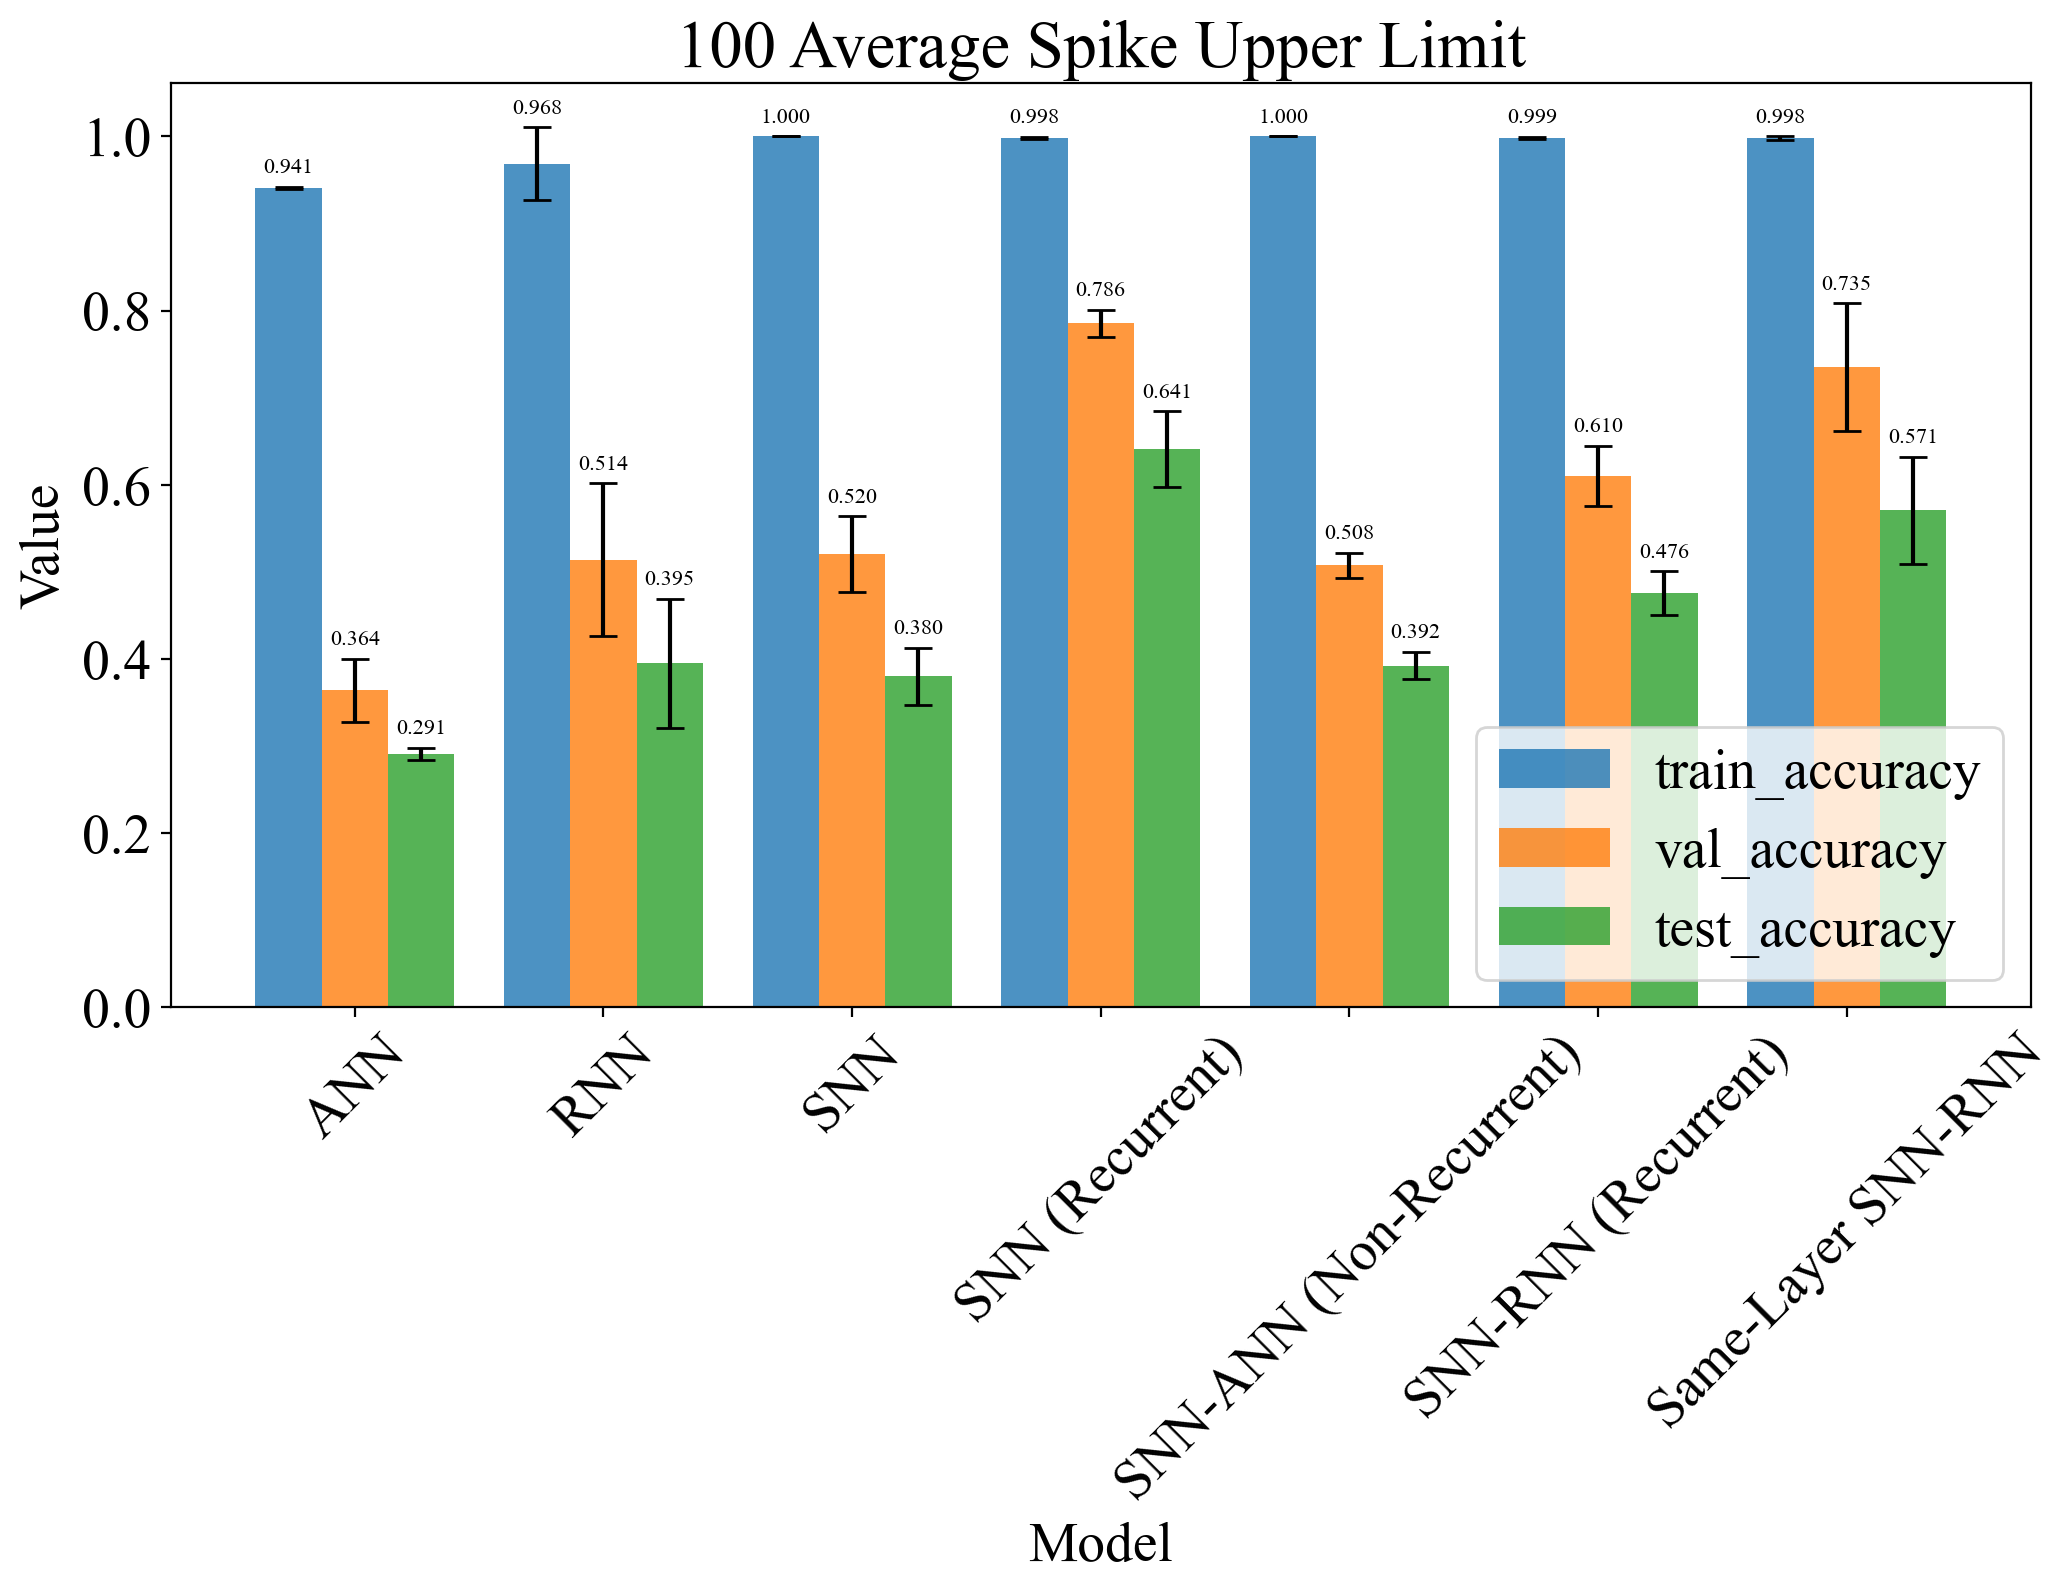

In [ ]:
# Create a bar chart showing the distribution of "value" for each "metric" across different "run_group" settings (metrics next to each other)
def plot_metric_distribution(df_means, metrics, ax=None, title=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6))
    
    # Get unique run groups and sort them
    run_groups = sorted(df_means['run_group'].unique())
    
    # Set up positioning for grouped bars
    bar_width = 0.8 / len(metrics)  # Width of each bar
    x_positions = np.arange(len(run_groups))  # Base positions for each run group
    
    # Plot each metric with offset positions
    for i, metric in enumerate(metrics):
        # Filter the dataframe for the current metric
        df_metric = df_means[df_means['metric'] == metric]
        
        # Create a list of values for each run group (in order)
        values = []
        std_values = []
        for group in run_groups:
            group_data = df_metric[df_metric['run_group'] == group]
            if not group_data.empty:
                values.append(group_data['mean_value'].iloc[0])
                std_values.append(group_data['std_value'].iloc[0])
            else:
                values.append(0)  # Default value if no data
                std_values.append(0)
        
        # Calculate x position with offset for this metric
        x_offset = x_positions + (i - len(metrics)/2 + 0.5) * bar_width
        
        # Plot bars for this metric
        bars = ax.bar(x_offset, values, bar_width, yerr=std_values, capsize=5, 
               label=metric, alpha=0.8)
        
        # Add value labels on top of bars
        for j, (bar, value) in enumerate(zip(bars, values)):
            if value > 0:  # Only add label if there's a meaningful value
                ax.text(bar.get_x() + bar.get_width()/2., value + (std_values[j] if std_values[j] > 0 else 0) + 0.01,
                       f'{value:.3f}', ha='center', va='bottom', fontsize=8, rotation=0)
    
    # Set x-axis labels and positions
    ax.set_xticks(x_positions)
    ax.set_xticklabels(run_groups, rotation=45)
    
    ax.set_title(title)
    ax.set_ylabel('Value')
    ax.set_xlabel('Model')
    ax.legend()
    # plt.tight_layout()
    return ax

# Plot the metrics
metrics = ['train_accuracy', 'val_accuracy', 'test_accuracy']
plot_metric_distribution(filtered_means, metrics, title="100 Average Spike Upper Limit")

<Axes: title={'center': 'Average Spikes Given 100 Average Spike Upper Limit'}, xlabel='Model', ylabel='Value'>

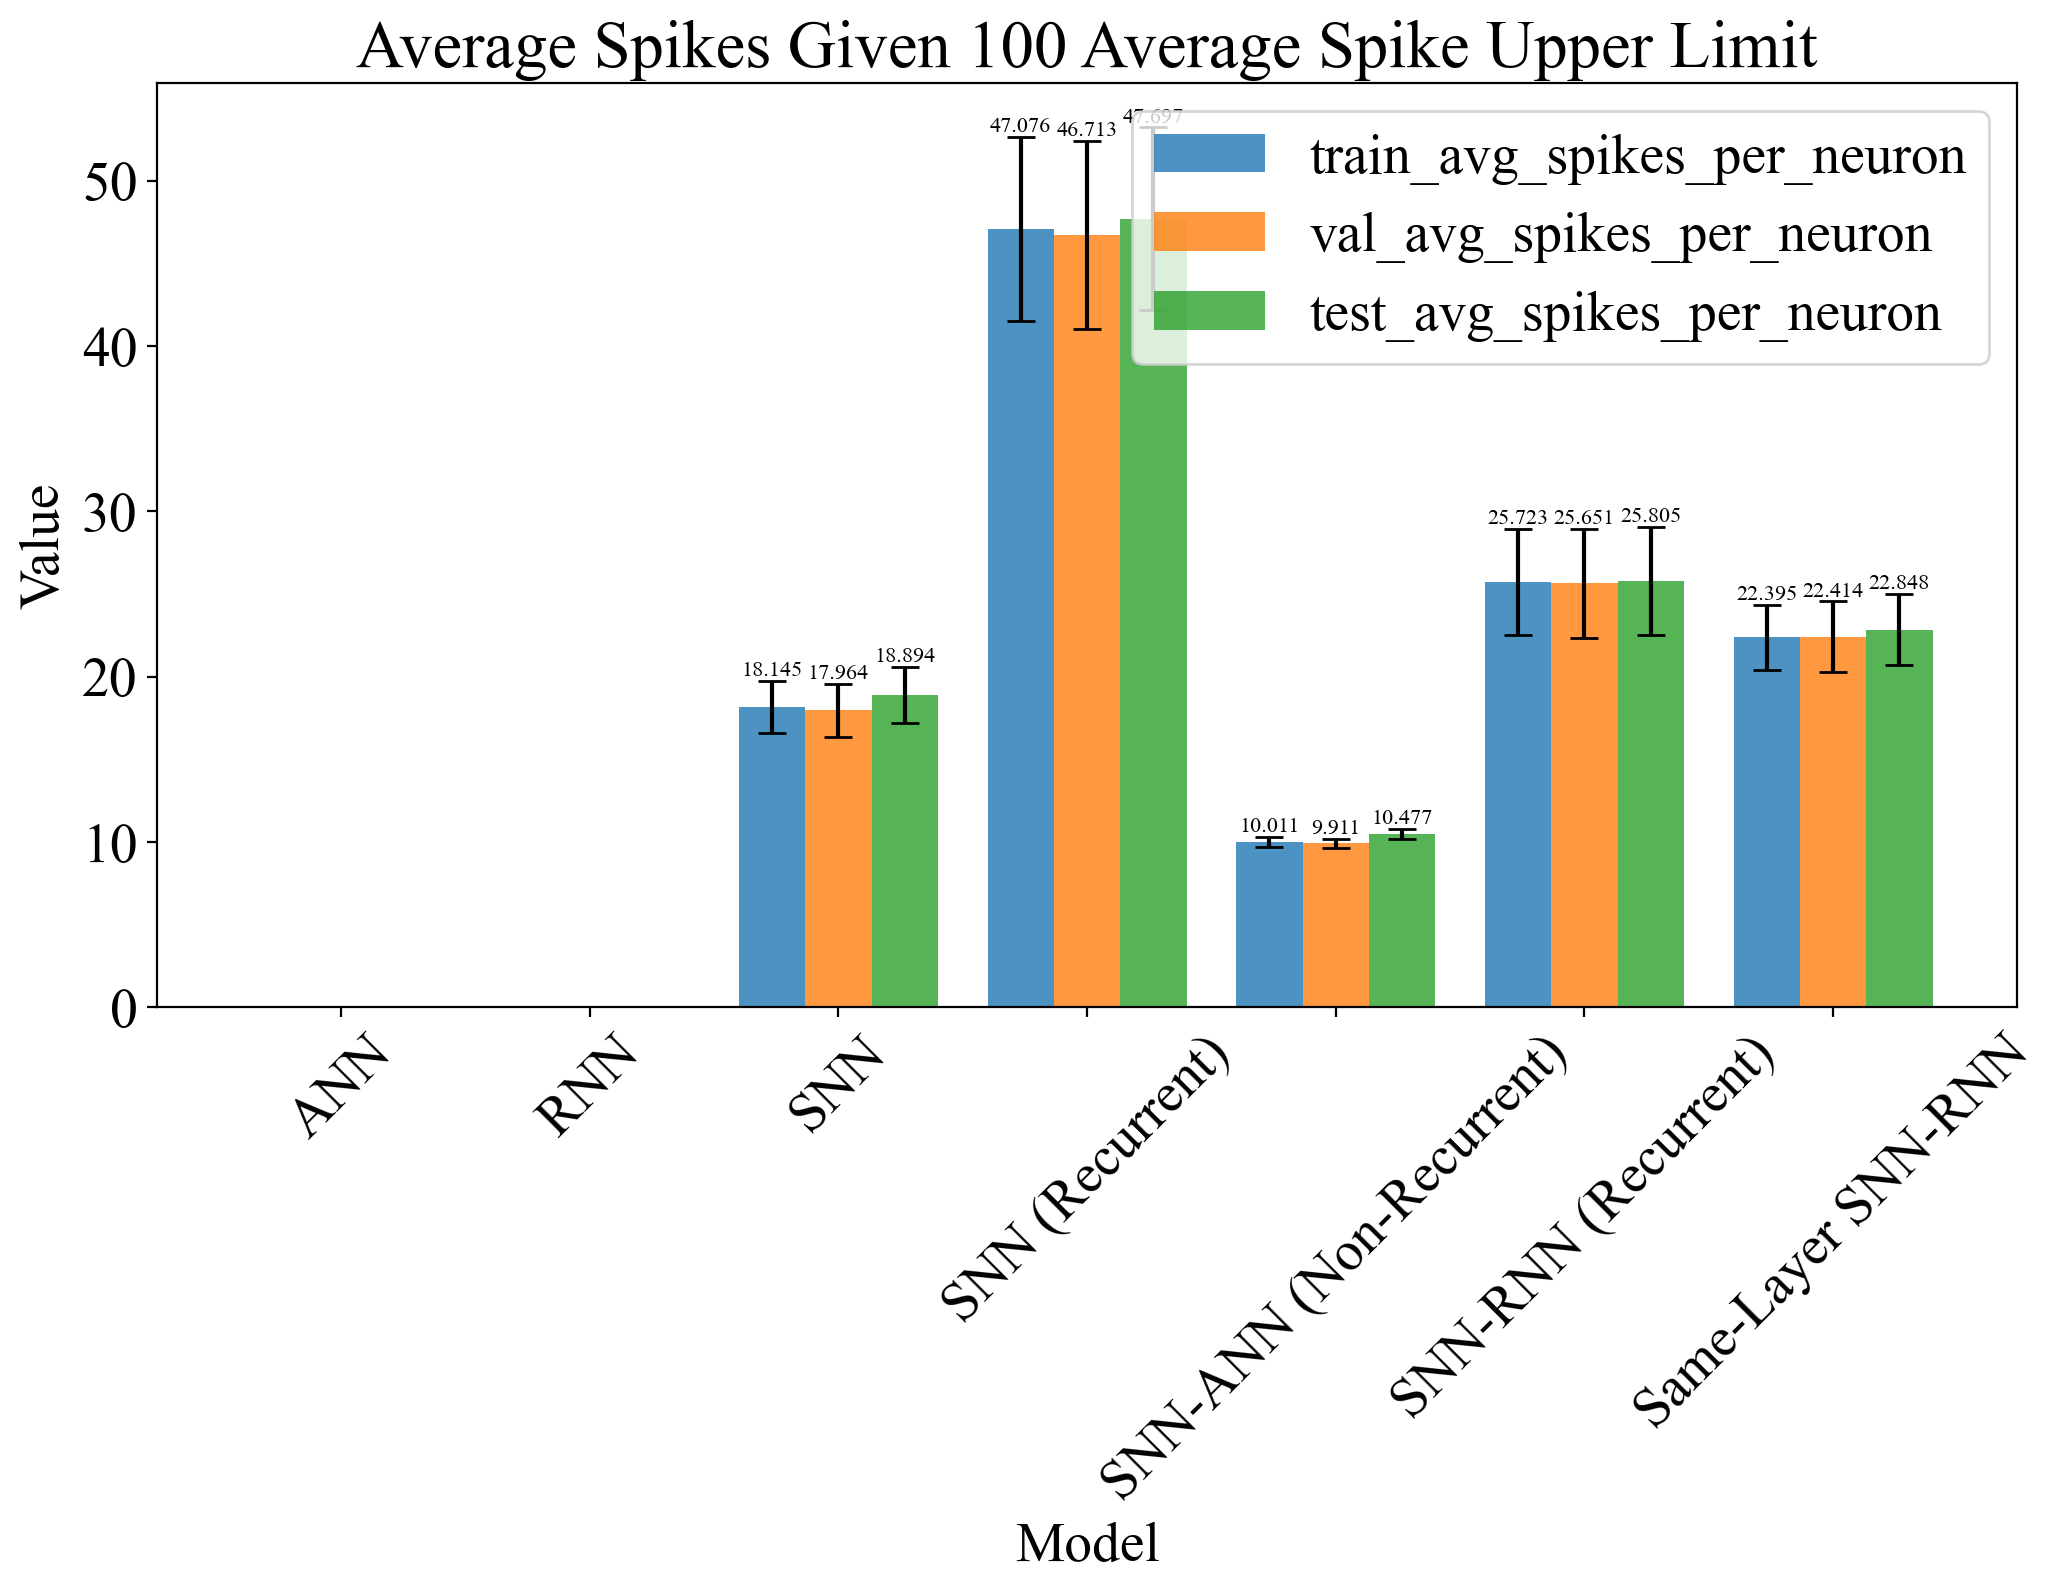

In [106]:
# Optimal SNN parameters - no upper bound
optimal_snn_params = {
    'v1_upper': [100, 'Missing'],
    'spike_grad_scale': [10, 'Missing'], 
    'data_config.nb_hidden': 256,
    'data_config.percent_data': 1.0
}
filtered_means = filter_means(df_means, optimal_snn_params)

remapping = {
    "SNN_rec_False_cross_entropy": "SNN",
    "SNN_rec_True_cross_entropy": "SNN (Recurrent)",
    "ANN_with_LIF_output_rec_False_cross_entropy": "ANN",
    "ANN_with_LIF_output_rec_True_cross_entropy": "RNN",
    "Hybrid_RNN_SNN_rec_rec_False_cross_entropy": "SNN-ANN (Non-Recurrent)",
    "Hybrid_RNN_SNN_rec_rec_True_cross_entropy": "SNN-RNN (Recurrent)",
    "Hybrid_RNN_SNN_V1_same_layer_rec_True_cross_entropy": "Same-Layer SNN-RNN",
}
# Replace run_group values with remapped values
filtered_means['run_group'] = filtered_means['run_group'].replace(remapping)
# filtered_means['run_group'] = filtered_means['run_group'].replace(remapping)
filtered_means[filtered_means['run_group'] == 'ANN']

metrics = ['train_avg_spikes_per_neuron', 'val_avg_spikes_per_neuron', 'test_avg_spikes_per_neuron']
plot_metric_distribution(filtered_means, metrics, title="Average Spikes Given 100 Average Spike Upper Limit")

/var/folders/7b/0zqwym191dq_5jvhhbf5lfgr0000gn/T/ipykernel_23707/66394519.py:34: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_data = df_param[df_metric['run_group'] == group]
/var/folders/7b/0zqwym191dq_5jvhhbf5lfgr0000gn/T/ipykernel_23707/66394519.py:34: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_data = df_param[df_metric['run_group'] == group]
/var/folders/7b/0zqwym191dq_5jvhhbf5lfgr0000gn/T/ipykernel_23707/66394519.py:34: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_data = df_param[df_metric['run_group'] == group]
/var/folders/7b/0zqwym191dq_5jvhhbf5lfgr0000gn/T/ipykernel_23707/66394519.py:34: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_data = df_param[df_metric['run_group'] == group]
/var/folders/7b/0zqwym191dq_5jvhhbf5lfgr0000gn/T/ipykernel_23707/66394519.py:34: UserWarning: Boolean Series key will be reindexed to match Data

<Axes: title={'center': 'Test Accuracy by Average Spikes Upper Limit'}, xlabel='Model', ylabel='test_accuracy'>

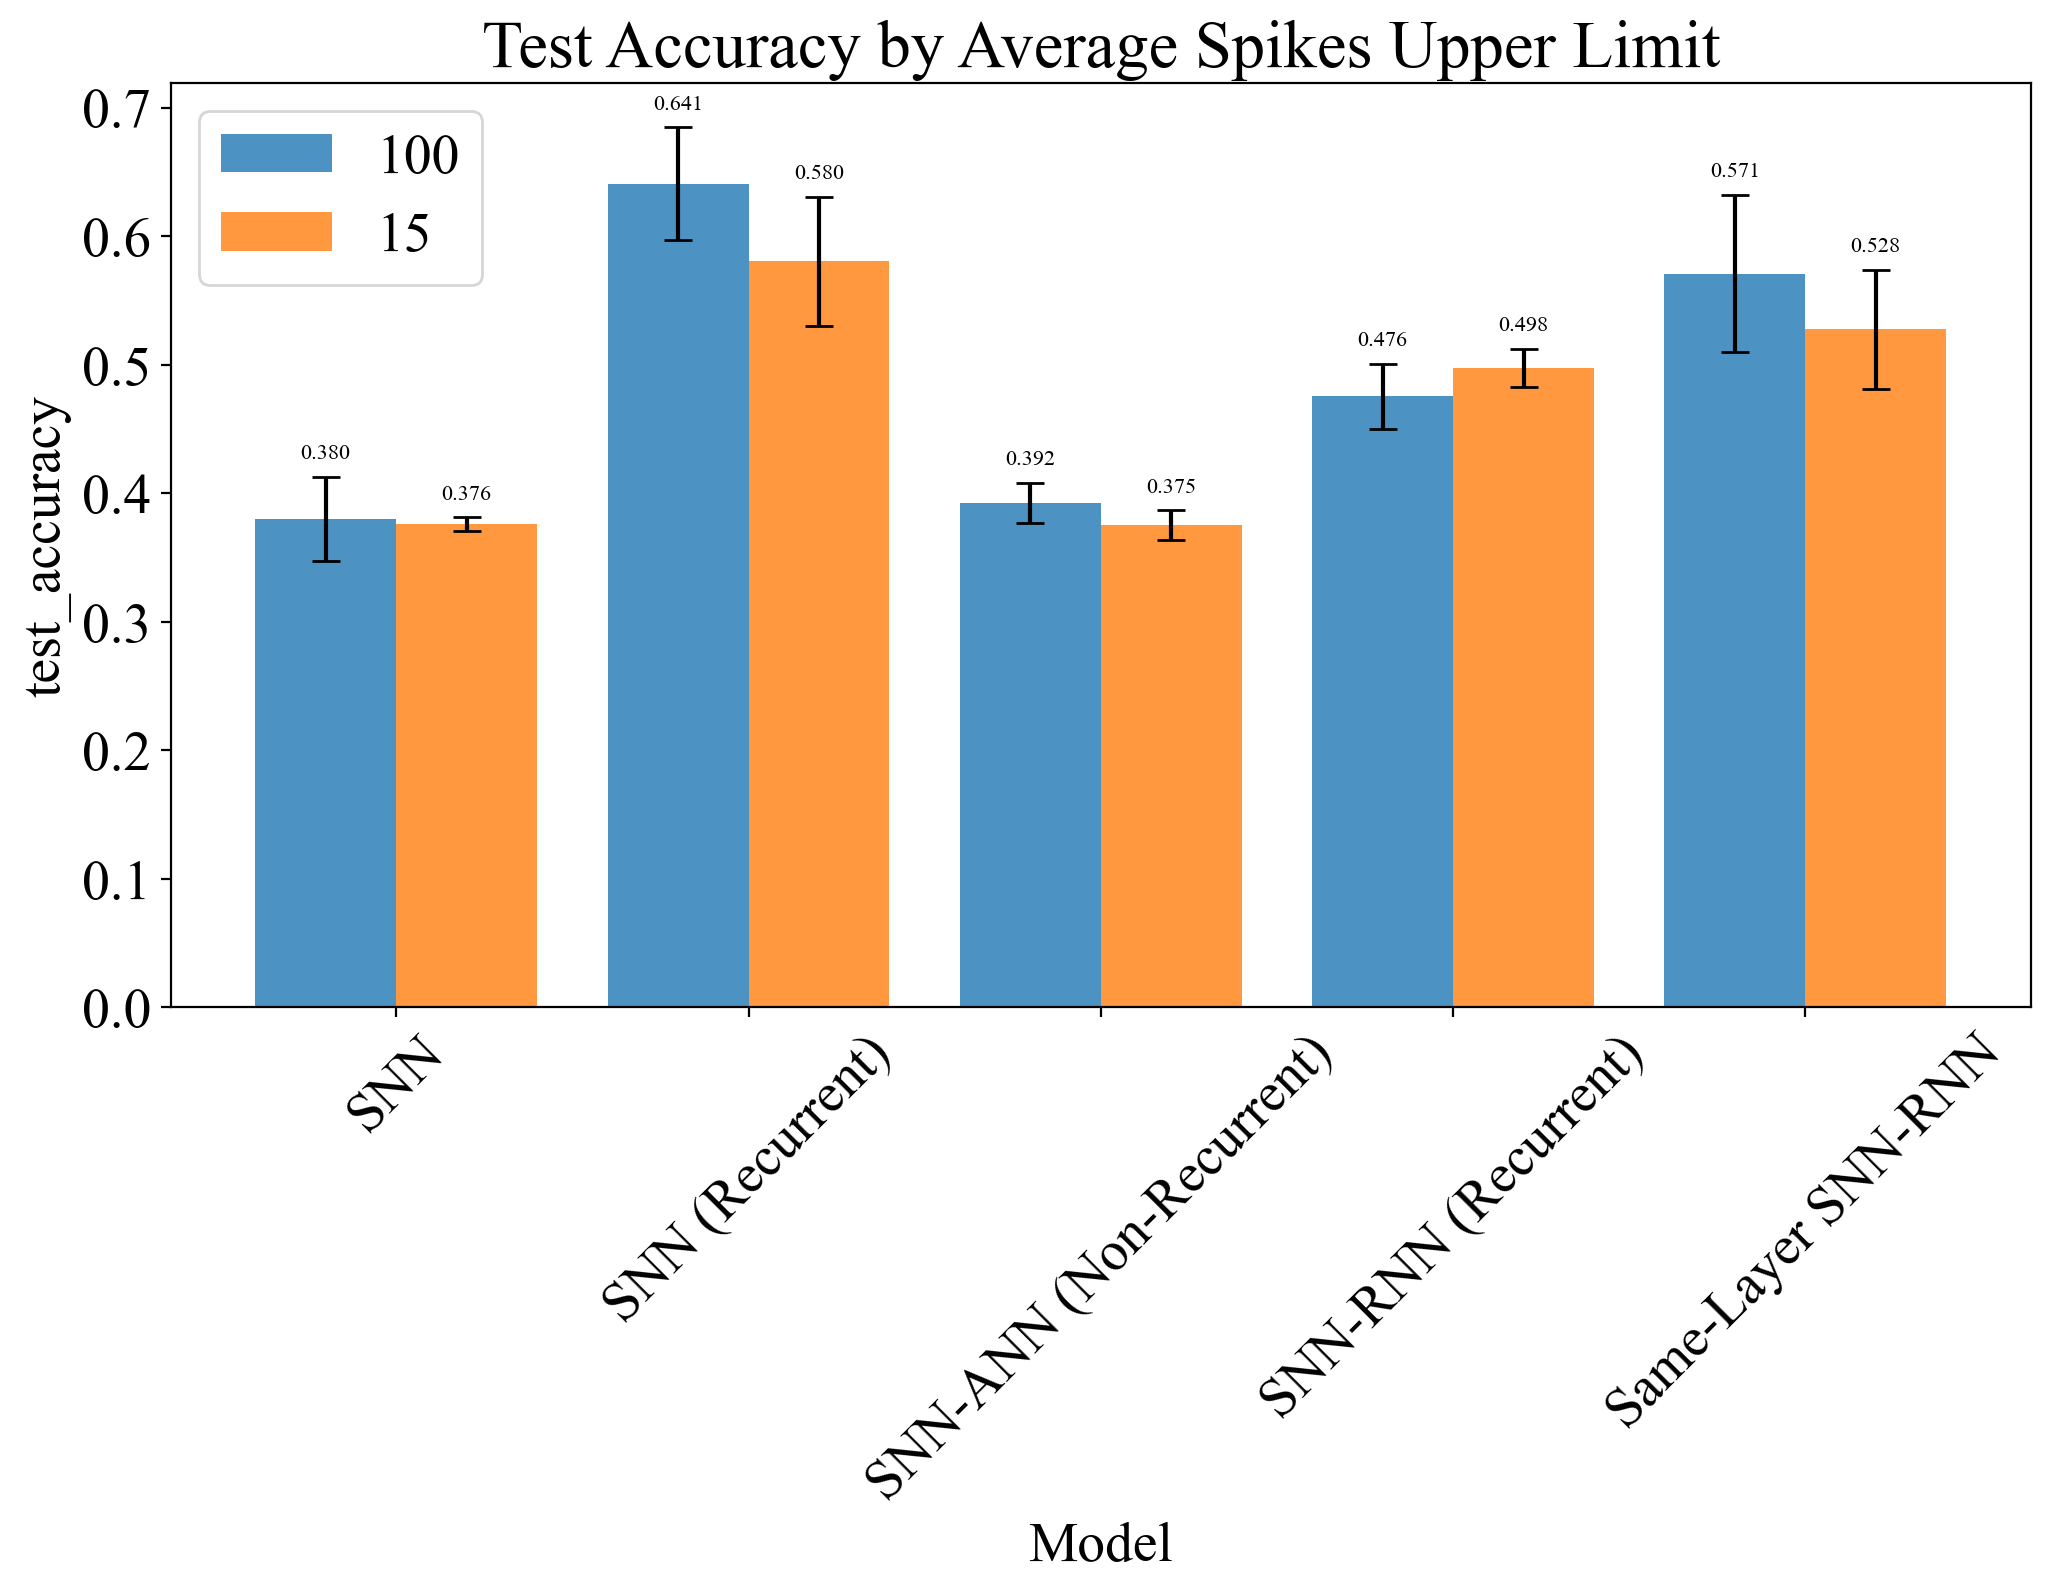

In [112]:
# Optimal SNN parameters - no upper bound
optimal_snn_params = {
    'v1_upper': [100, 15],
    'spike_grad_scale': [10], 
    'data_config.nb_hidden': 256,
    'data_config.percent_data': 1.0
}
filtered_means = filter_means(df_means, optimal_snn_params)
# Replace run_group values with remapped values
filtered_means['run_group'] = filtered_means['run_group'].replace(remapping)
# filtered_means['run_group'] = filtered_means['run_group'].replace(remapping)

def plot_metric_distribution_param_based(param_name, param_range, df_means, metric, title=None):
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Get unique run groups and sort them
    run_groups = sorted(df_means['run_group'].unique())
    
    # Set up positioning for grouped bars
    bar_width = 0.8 / len(param_range)  # Width of each bar
    x_positions = np.arange(len(run_groups))  # Base positions for each run group

    df_metric = df_means[df_means['metric'] == metric]

    # Plot each metric with offset positions
    for i, v in enumerate(param_range):
        # Filter the dataframe for the current metric
        df_param = df_metric[df_metric[param_name]==v]
        
        # Create a list of values for each run group (in order)
        values = []
        std_values = []
        for group in run_groups:
            group_data = df_param[df_metric['run_group'] == group]
            if not group_data.empty:
                values.append(group_data['mean_value'].iloc[0])
                std_values.append(group_data['std_value'].iloc[0])
            else:
                values.append(0)  # Default value if no data
                std_values.append(0)
        
        # Calculate x position with offset for this metric
        x_offset = x_positions + (i - len(param_range)/2 + 0.5) * bar_width
        
        # Plot bars for this metric
        bars = ax.bar(x_offset, values, bar_width, yerr=std_values, capsize=5, 
               label=v, alpha=0.8)
        
        # Add value labels on top of bars
        for j, (bar, value) in enumerate(zip(bars, values)):
            if value > 0:  # Only add label if there's a meaningful value
                ax.text(bar.get_x() + bar.get_width()/2., value + (std_values[j] if std_values[j] > 0 else 0) + 0.01,
                       f'{value:.3f}', ha='center', va='bottom', fontsize=8, rotation=0)
    
    # Set x-axis labels and positions
    ax.set_xticks(x_positions)
    ax.set_xticklabels(run_groups, rotation=45)
    
    ax.set_title(title)
    ax.set_ylabel(metric)
    ax.set_xlabel('Model')
    ax.legend()
    # plt.tight_layout()
    return ax
param = 'v1_upper'
metric = 'test_accuracy'
plot_metric_distribution_param_based(param, optimal_snn_params[param], filtered_means, metric, "Test Accuracy by Average Spikes Upper Limit")

<Axes: title={'center': '25% of Hidden Neurons'}, xlabel='Model', ylabel='Value'>

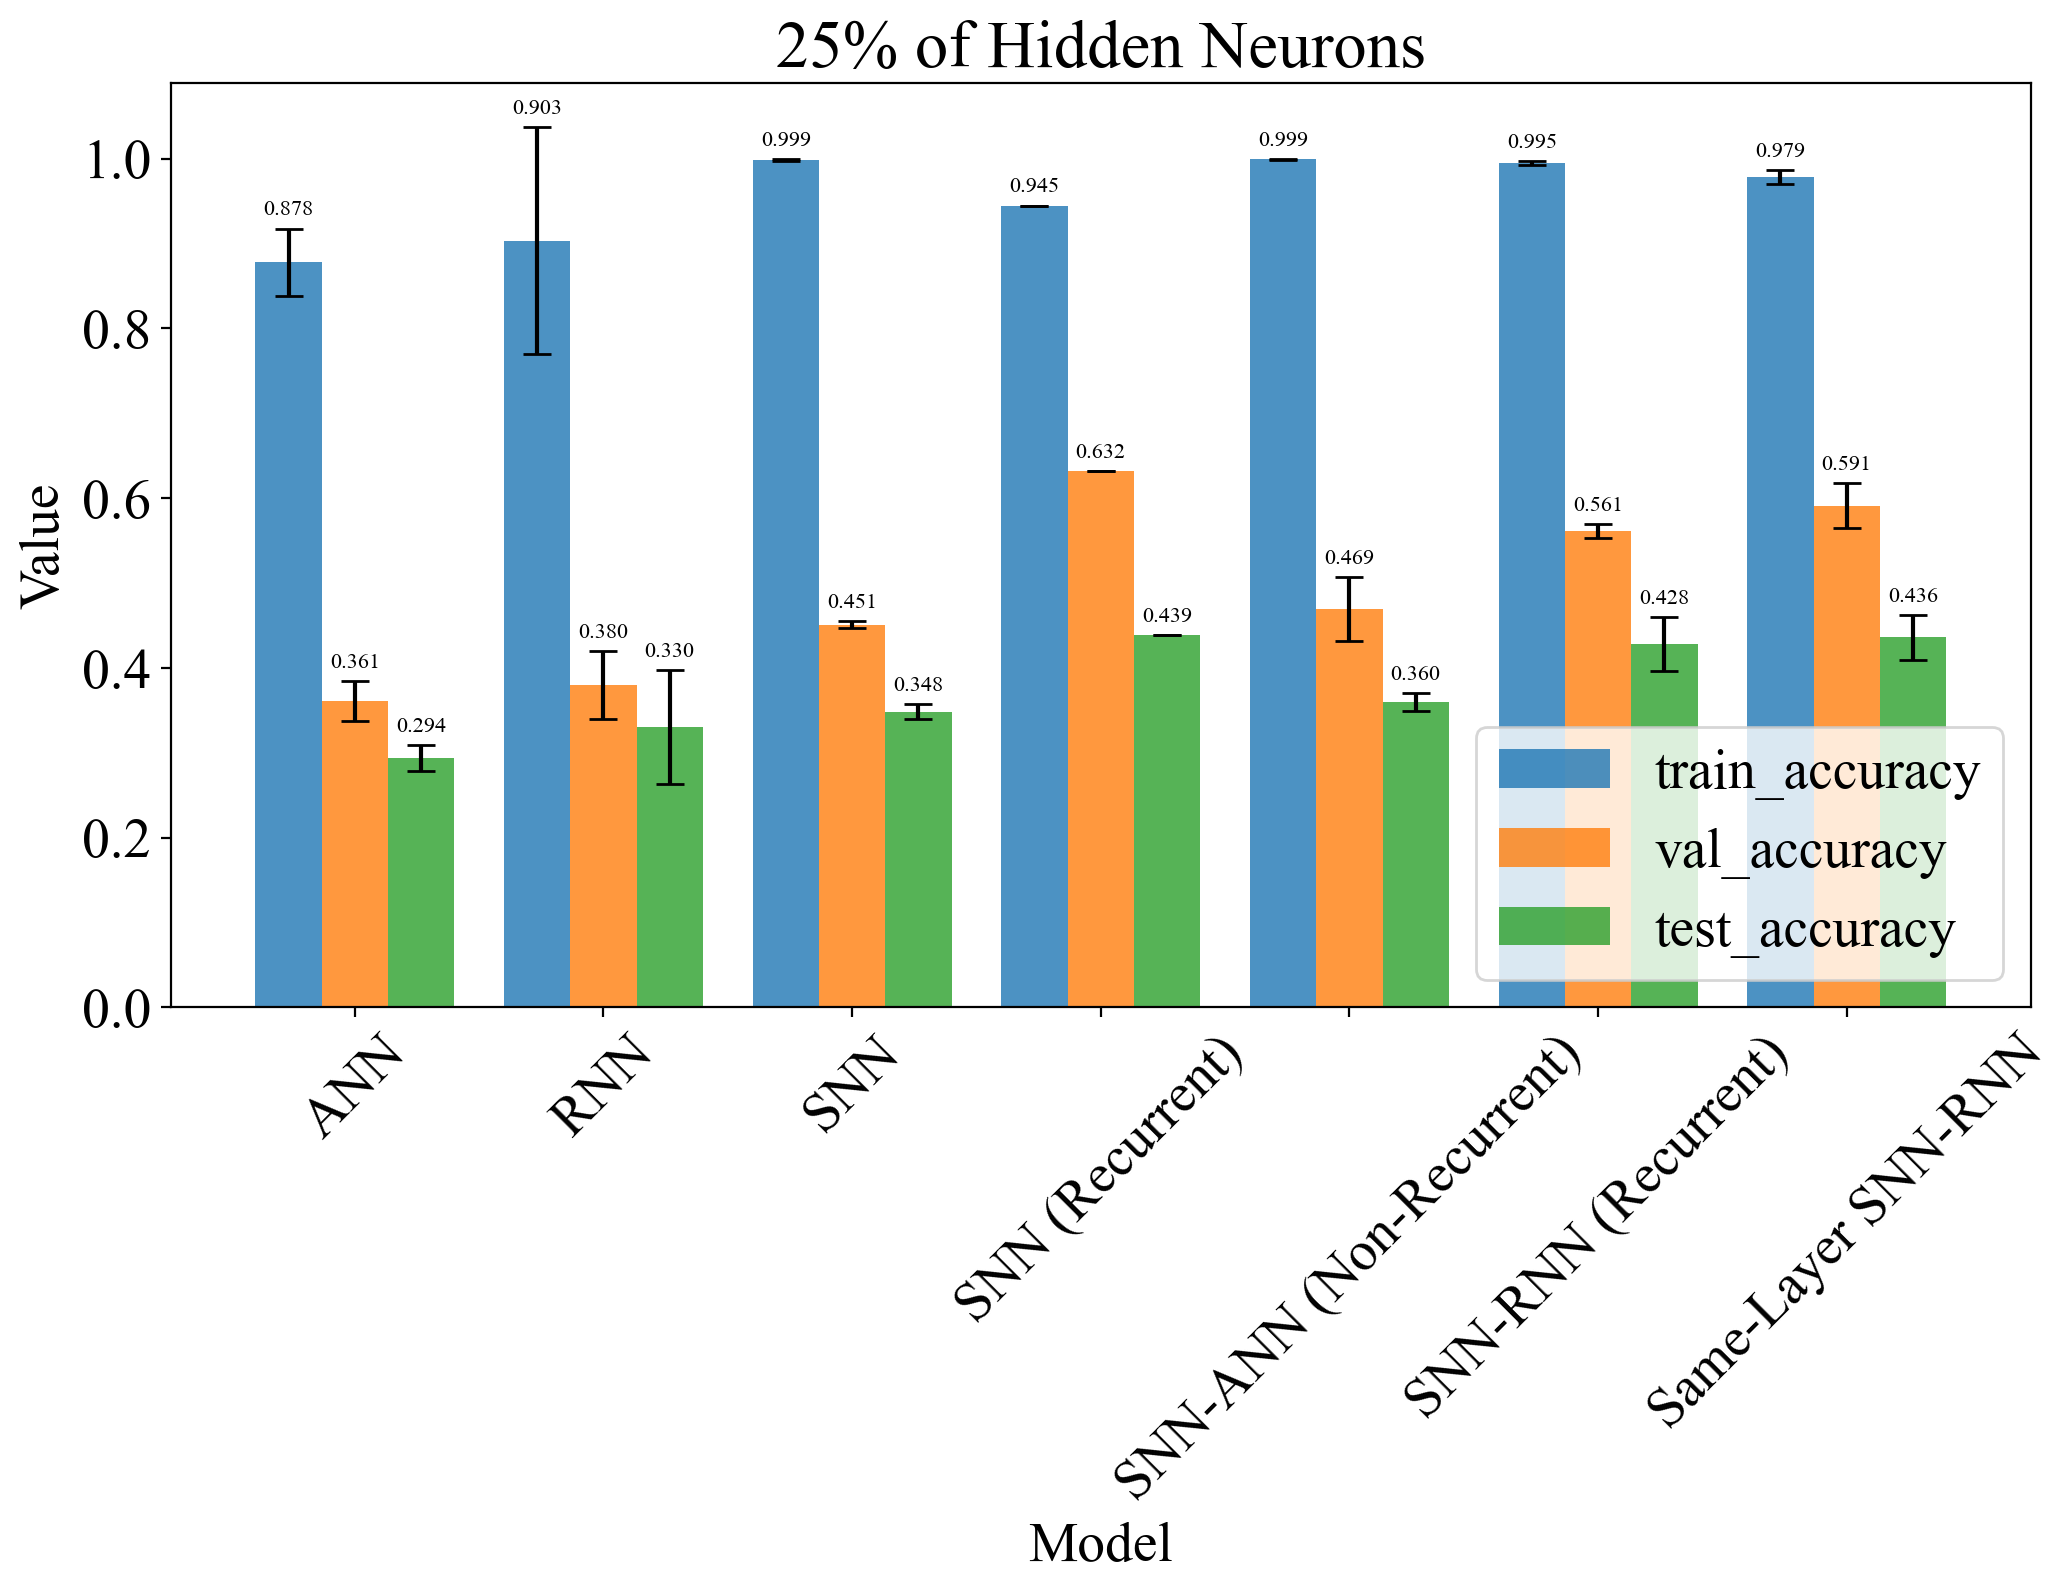

In [95]:
# Optimal SNN parameters - no upper bound
optimal_snn_params = {
    'v1_upper': [100, 'Missing'],
    'spike_grad_scale': [10, 'Missing'], 
    'data_config.nb_hidden': 64,
    'data_config.percent_data': 1.0
}
filtered_means = filter_means(df_means, optimal_snn_params)

remapping = {
    "SNN_rec_False_cross_entropy": "SNN",
    "SNN_rec_True_cross_entropy": "SNN (Recurrent)",
    "ANN_with_LIF_output_rec_False_cross_entropy": "ANN",
    "ANN_with_LIF_output_rec_True_cross_entropy": "RNN",
    "Hybrid_RNN_SNN_rec_rec_False_cross_entropy": "SNN-ANN (Non-Recurrent)",
    "Hybrid_RNN_SNN_rec_rec_True_cross_entropy": "SNN-RNN (Recurrent)",
    "Hybrid_RNN_SNN_V1_same_layer_rec_True_cross_entropy": "Same-Layer SNN-RNN",
}
# Replace run_group values with remapped values
filtered_means['run_group'] = filtered_means['run_group'].replace(remapping)
# filtered_means['run_group'] = filtered_means['run_group'].replace(remapping)

metrics = ['train_accuracy', 'val_accuracy', 'test_accuracy']
plot_metric_distribution(filtered_means, metrics, title="25% of Hidden Neurons")

/var/folders/7b/0zqwym191dq_5jvhhbf5lfgr0000gn/T/ipykernel_23707/66394519.py:34: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_data = df_param[df_metric['run_group'] == group]
/var/folders/7b/0zqwym191dq_5jvhhbf5lfgr0000gn/T/ipykernel_23707/66394519.py:34: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_data = df_param[df_metric['run_group'] == group]
/var/folders/7b/0zqwym191dq_5jvhhbf5lfgr0000gn/T/ipykernel_23707/66394519.py:34: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_data = df_param[df_metric['run_group'] == group]
/var/folders/7b/0zqwym191dq_5jvhhbf5lfgr0000gn/T/ipykernel_23707/66394519.py:34: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_data = df_param[df_metric['run_group'] == group]
/var/folders/7b/0zqwym191dq_5jvhhbf5lfgr0000gn/T/ipykernel_23707/66394519.py:34: UserWarning: Boolean Series key will be reindexed to match Data

<Axes: title={'center': 'Test Accuracy by Average Spikes Upper Limit, 25% of Neurons'}, xlabel='Model', ylabel='test_accuracy'>

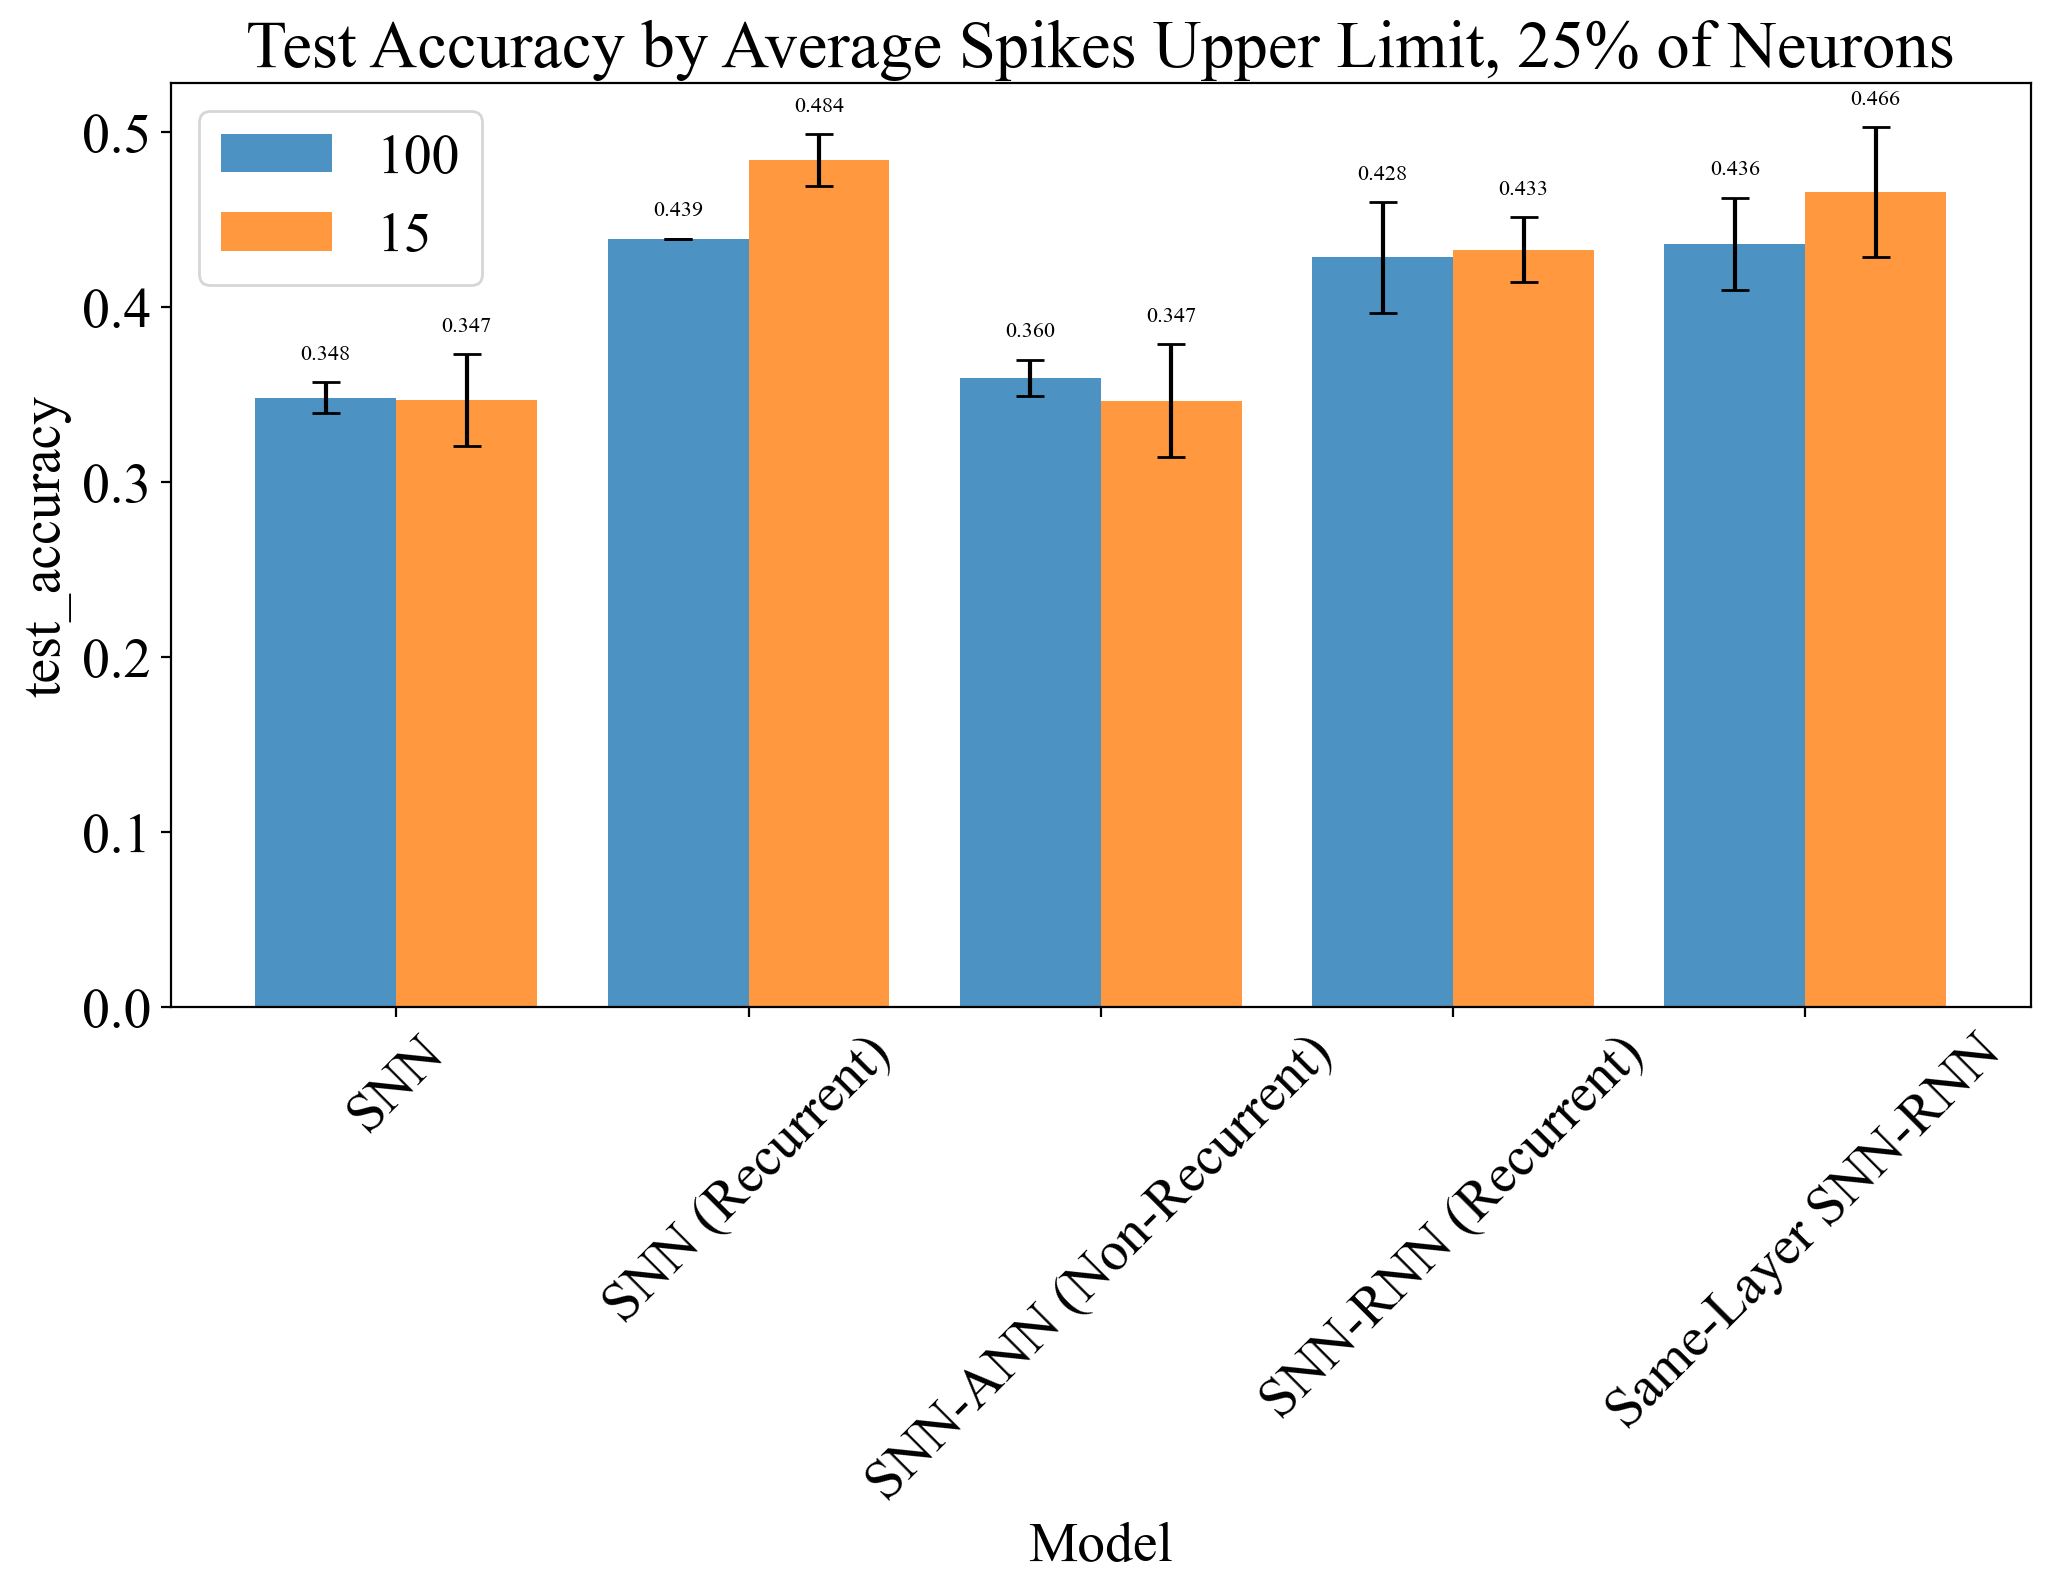

In [113]:
# Optimal SNN parameters - no upper bound
optimal_snn_params = {
    'v1_upper': [100, 15],
    'spike_grad_scale': [10], 
    'data_config.nb_hidden': 64,
    'data_config.percent_data': 1.0
}
filtered_means = filter_means(df_means, optimal_snn_params)
# Replace run_group values with remapped values
filtered_means['run_group'] = filtered_means['run_group'].replace(remapping)
# filtered_means['run_group'] = filtered_means['run_group'].replace(remapping)
param = 'v1_upper'
metric = 'test_accuracy'
plot_metric_distribution_param_based(param, optimal_snn_params[param], filtered_means, metric,  "Test Accuracy by Average Spikes Upper Limit, 25% of Neurons")

/var/folders/7b/0zqwym191dq_5jvhhbf5lfgr0000gn/T/ipykernel_23707/2587110462.py:34: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_data = df_param[df_metric['run_group'] == group]
/var/folders/7b/0zqwym191dq_5jvhhbf5lfgr0000gn/T/ipykernel_23707/2587110462.py:34: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_data = df_param[df_metric['run_group'] == group]
/var/folders/7b/0zqwym191dq_5jvhhbf5lfgr0000gn/T/ipykernel_23707/2587110462.py:34: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_data = df_param[df_metric['run_group'] == group]
/var/folders/7b/0zqwym191dq_5jvhhbf5lfgr0000gn/T/ipykernel_23707/2587110462.py:34: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_data = df_param[df_metric['run_group'] == group]
/var/folders/7b/0zqwym191dq_5jvhhbf5lfgr0000gn/T/ipykernel_23707/2587110462.py:34: UserWarning: Boolean Series key will be reindexed to 

<Axes: title={'center': 'Test Accuracy for 100 Spike Upper Limit, by Number of Hidden Neurons'}, xlabel='Model', ylabel='test_accuracy'>

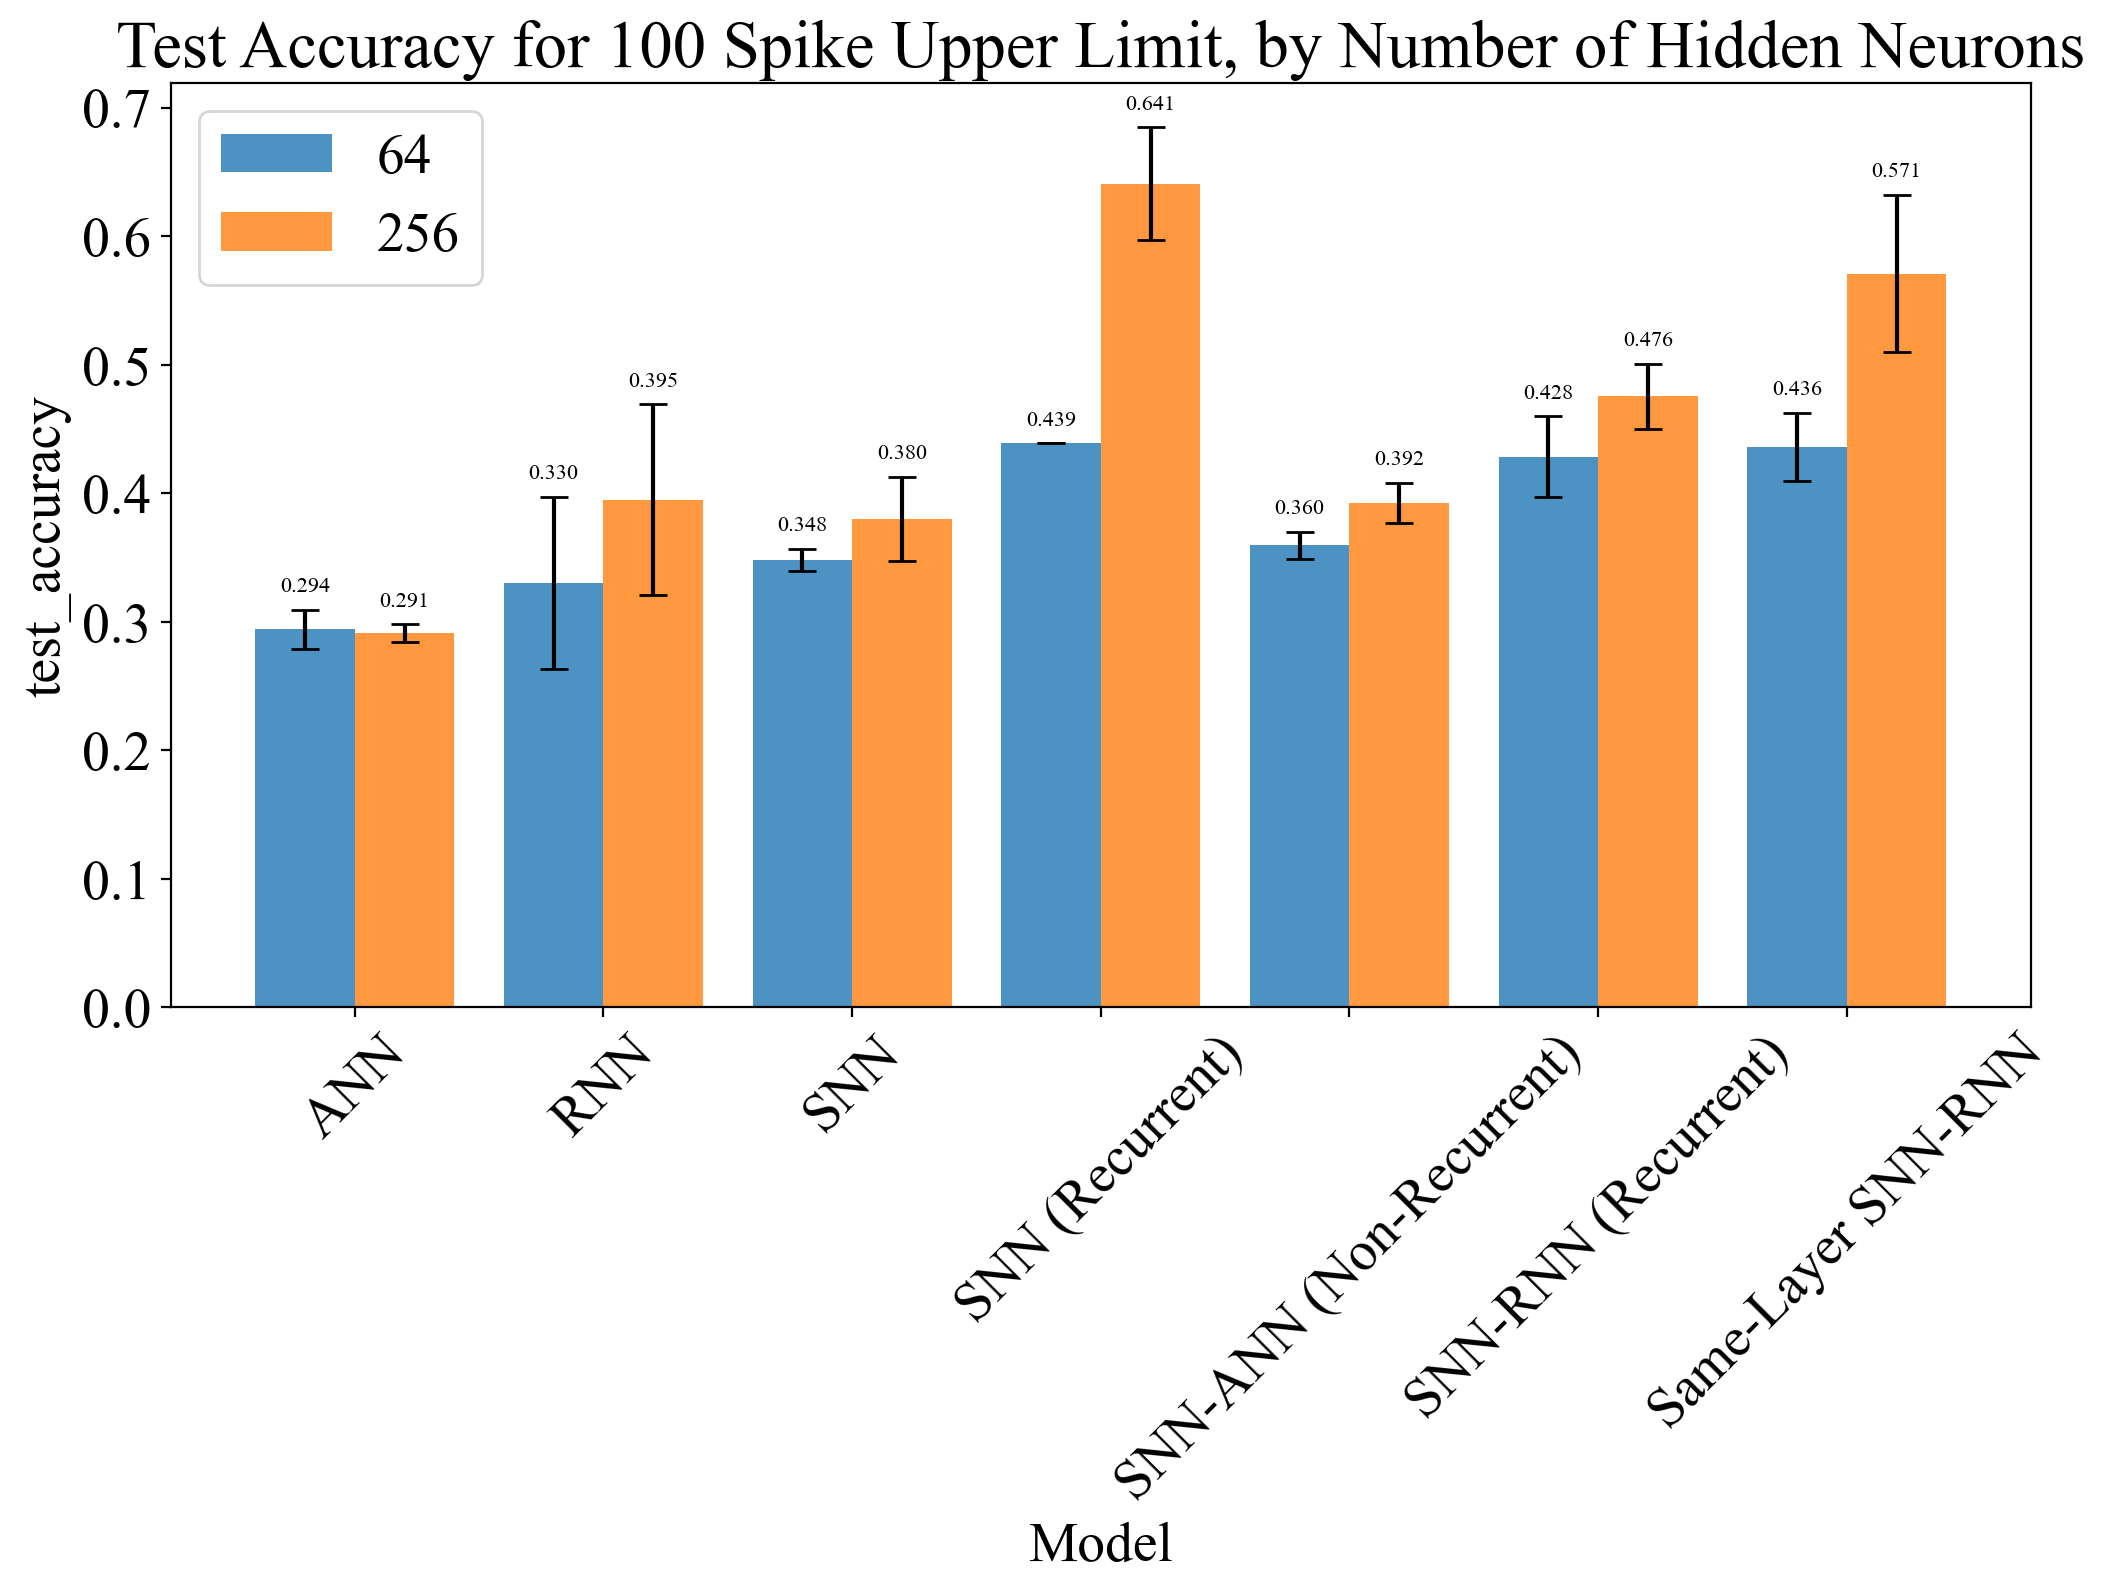

In [111]:
# Optimal SNN parameters - no upper bound
optimal_snn_params = {
    'v1_upper': [100, "Missing"],
    'spike_grad_scale': [10, "Missing"], 
    'data_config.nb_hidden': [64, 256],
    'data_config.percent_data': 1.0
}
filtered_means = filter_means(df_means, optimal_snn_params)
# Replace run_group values with remapped values
filtered_means['run_group'] = filtered_means['run_group'].replace(remapping)
# filtered_means['run_group'] = filtered_means['run_group'].replace(remapping)
param = 'data_config.nb_hidden'
metric = 'test_accuracy'
plot_metric_distribution_param_based(param, optimal_snn_params[param], filtered_means, metric,  "Test Accuracy for 100 Spike Upper Limit, by Number of Hidden Neurons")

<Axes: title={'center': 'Average Spikes Given 100 Average Spike Upper Limit, 25% of Neurons'}, xlabel='Model', ylabel='Value'>

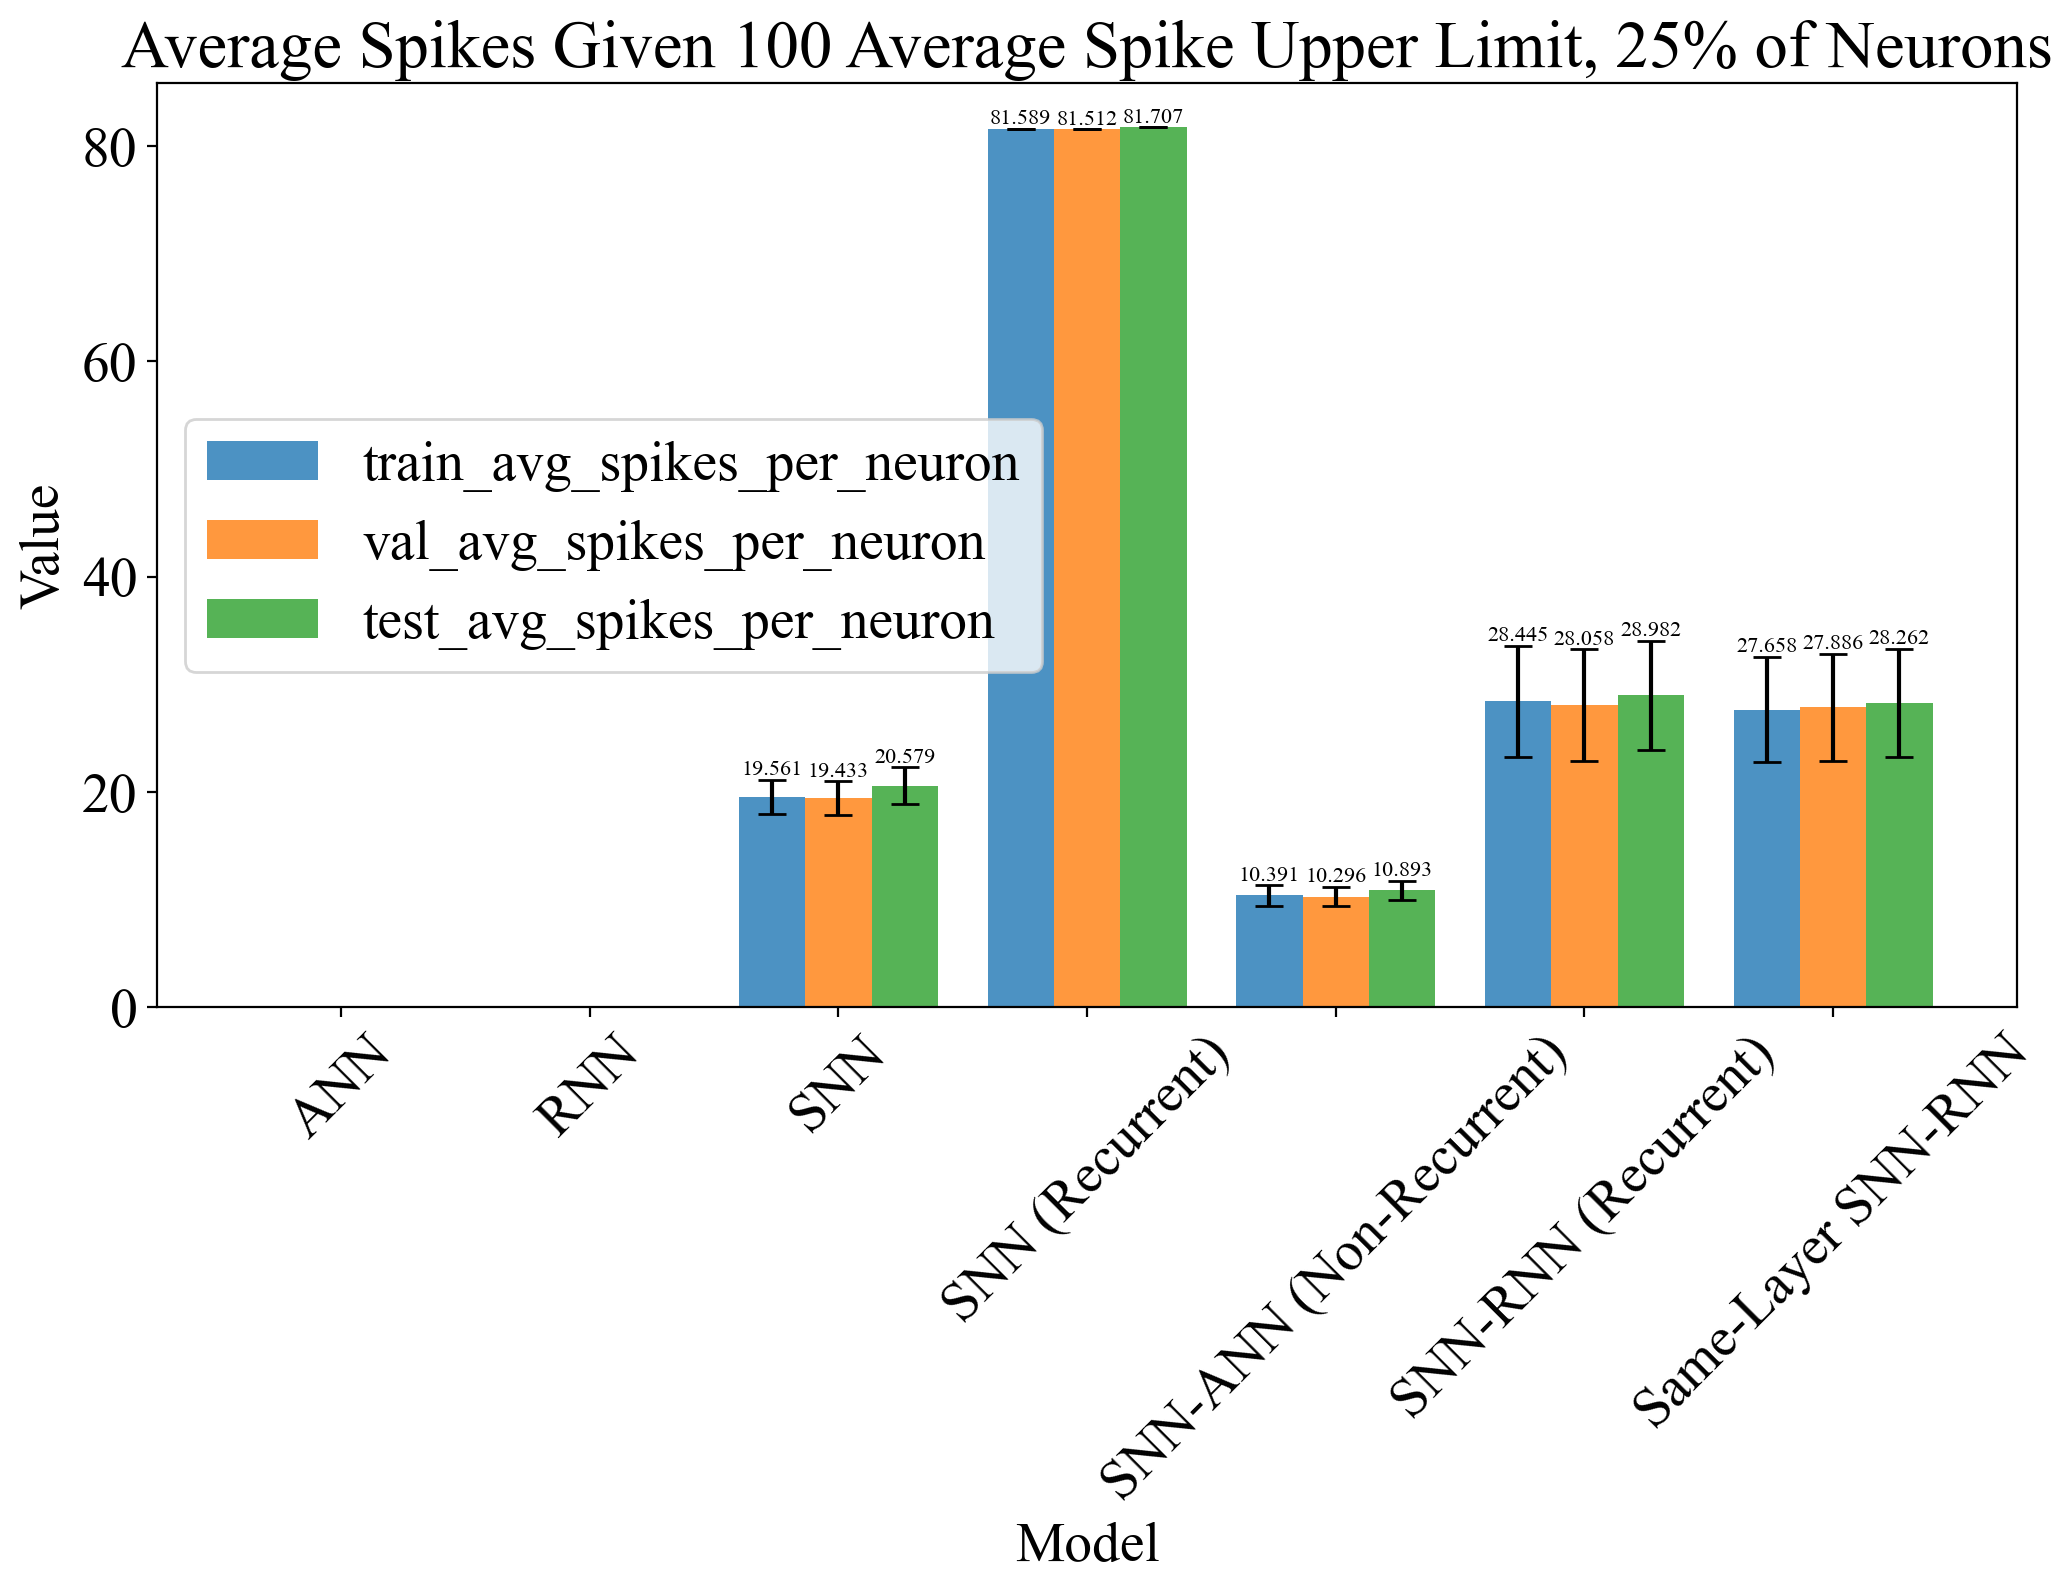

In [120]:
# Optimal SNN parameters - no upper bound
optimal_snn_params = {
    'v1_upper': [100, 'Missing'],
    'spike_grad_scale': [10, 'Missing'], 
    'data_config.nb_hidden': 64,
    'data_config.percent_data': 1.0
}
filtered_means = filter_means(df_means, optimal_snn_params)

remapping = {
    "SNN_rec_False_cross_entropy": "SNN",
    "SNN_rec_True_cross_entropy": "SNN (Recurrent)",
    "ANN_with_LIF_output_rec_False_cross_entropy": "ANN",
    "ANN_with_LIF_output_rec_True_cross_entropy": "RNN",
    "Hybrid_RNN_SNN_rec_rec_False_cross_entropy": "SNN-ANN (Non-Recurrent)",
    "Hybrid_RNN_SNN_rec_rec_True_cross_entropy": "SNN-RNN (Recurrent)",
    "Hybrid_RNN_SNN_V1_same_layer_rec_True_cross_entropy": "Same-Layer SNN-RNN",
}
# Replace run_group values with remapped values
filtered_means['run_group'] = filtered_means['run_group'].replace(remapping)
# filtered_means['run_group'] = filtered_means['run_group'].replace(remapping)
filtered_means[filtered_means['run_group'] == 'ANN']

metrics = ['train_avg_spikes_per_neuron', 'val_avg_spikes_per_neuron', 'test_avg_spikes_per_neuron']
plot_metric_distribution(filtered_means, metrics, title="Average Spikes Given 100 Average Spike Upper Limit, 25% of Neurons")

<Axes: title={'center': '25% of Data'}, xlabel='Model', ylabel='Value'>

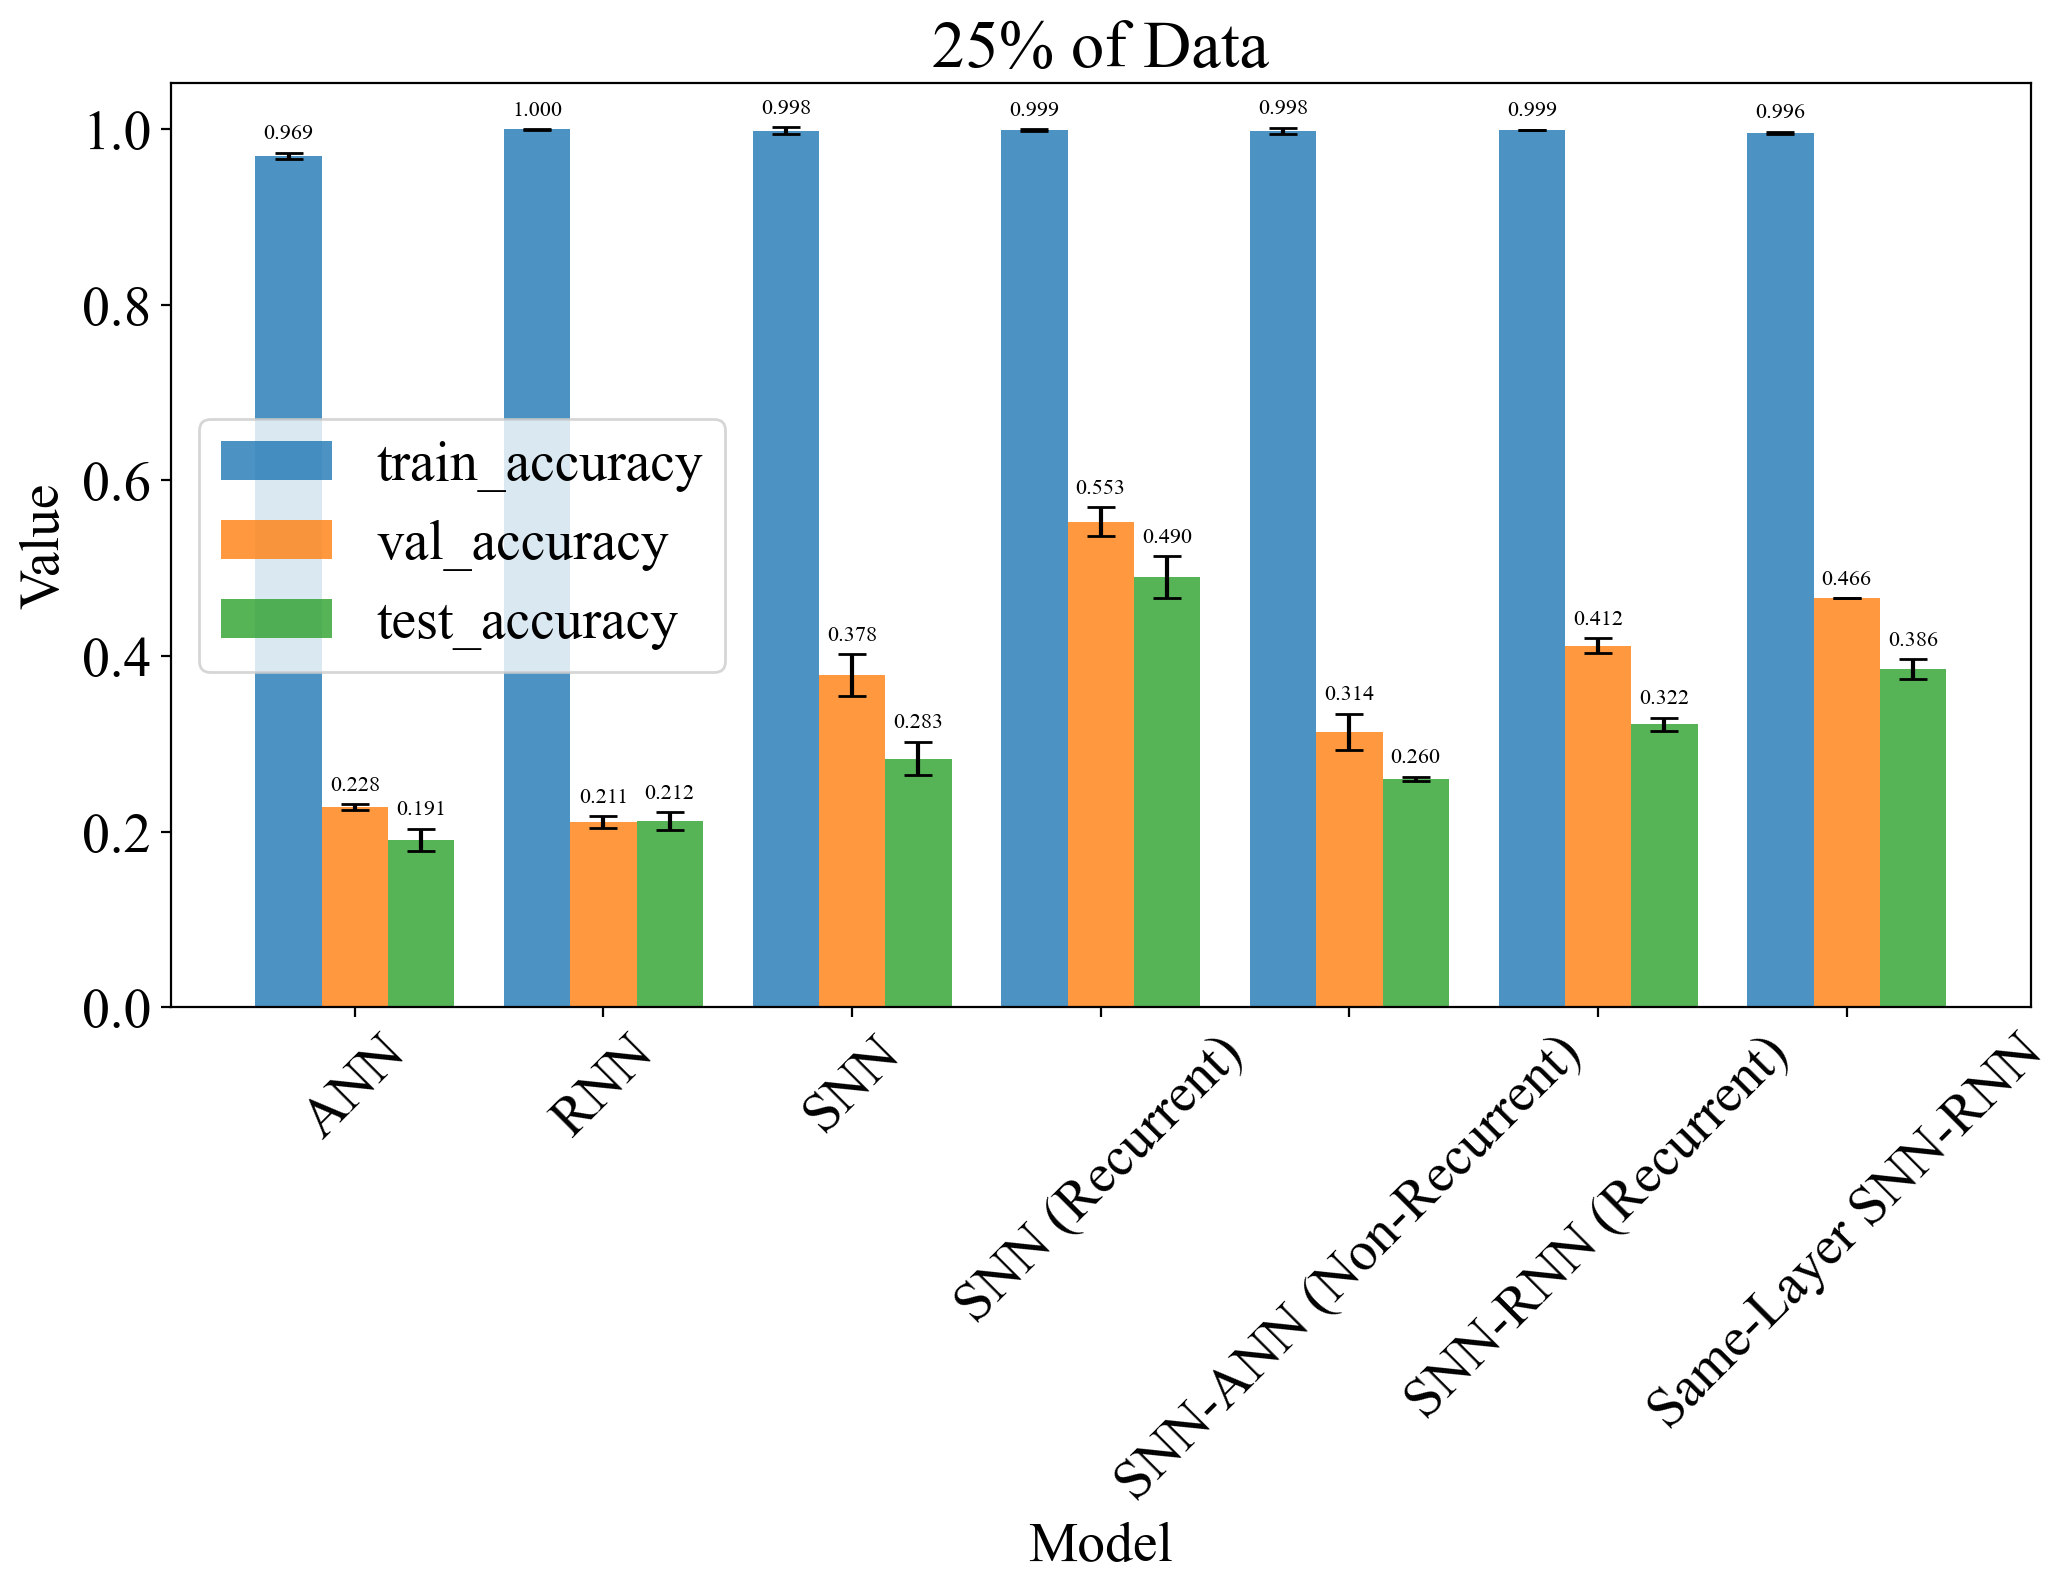

In [96]:
# Optimal SNN parameters - no upper bound
optimal_snn_params = {
    'v1_upper': [100, 'Missing'],
    'spike_grad_scale': [10, 'Missing'], 
    'data_config.nb_hidden': 256,
    'data_config.percent_data': 0.25
}
filtered_means = filter_means(df_means, optimal_snn_params)

remapping = {
    "SNN_rec_False_cross_entropy": "SNN",
    "SNN_rec_True_cross_entropy": "SNN (Recurrent)",
    "ANN_with_LIF_output_rec_False_cross_entropy": "ANN",
    "ANN_with_LIF_output_rec_True_cross_entropy": "RNN",
    "Hybrid_RNN_SNN_rec_rec_False_cross_entropy": "SNN-ANN (Non-Recurrent)",
    "Hybrid_RNN_SNN_rec_rec_True_cross_entropy": "SNN-RNN (Recurrent)",
    "Hybrid_RNN_SNN_V1_same_layer_rec_True_cross_entropy": "Same-Layer SNN-RNN",
}
# Replace run_group values with remapped values
filtered_means['run_group'] = filtered_means['run_group'].replace(remapping)
# filtered_means['run_group'] = filtered_means['run_group'].replace(remapping)

metrics = ['train_accuracy', 'val_accuracy', 'test_accuracy']
plot_metric_distribution(filtered_means, metrics, title="25% of Data")

/var/folders/7b/0zqwym191dq_5jvhhbf5lfgr0000gn/T/ipykernel_23707/66394519.py:34: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_data = df_param[df_metric['run_group'] == group]
/var/folders/7b/0zqwym191dq_5jvhhbf5lfgr0000gn/T/ipykernel_23707/66394519.py:34: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_data = df_param[df_metric['run_group'] == group]
/var/folders/7b/0zqwym191dq_5jvhhbf5lfgr0000gn/T/ipykernel_23707/66394519.py:34: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_data = df_param[df_metric['run_group'] == group]
/var/folders/7b/0zqwym191dq_5jvhhbf5lfgr0000gn/T/ipykernel_23707/66394519.py:34: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_data = df_param[df_metric['run_group'] == group]
/var/folders/7b/0zqwym191dq_5jvhhbf5lfgr0000gn/T/ipykernel_23707/66394519.py:34: UserWarning: Boolean Series key will be reindexed to match Data

<Axes: title={'center': 'Test Accuracy by Average Spikes Upper Limit, 25% of Neurons'}, xlabel='Model', ylabel='test_accuracy'>

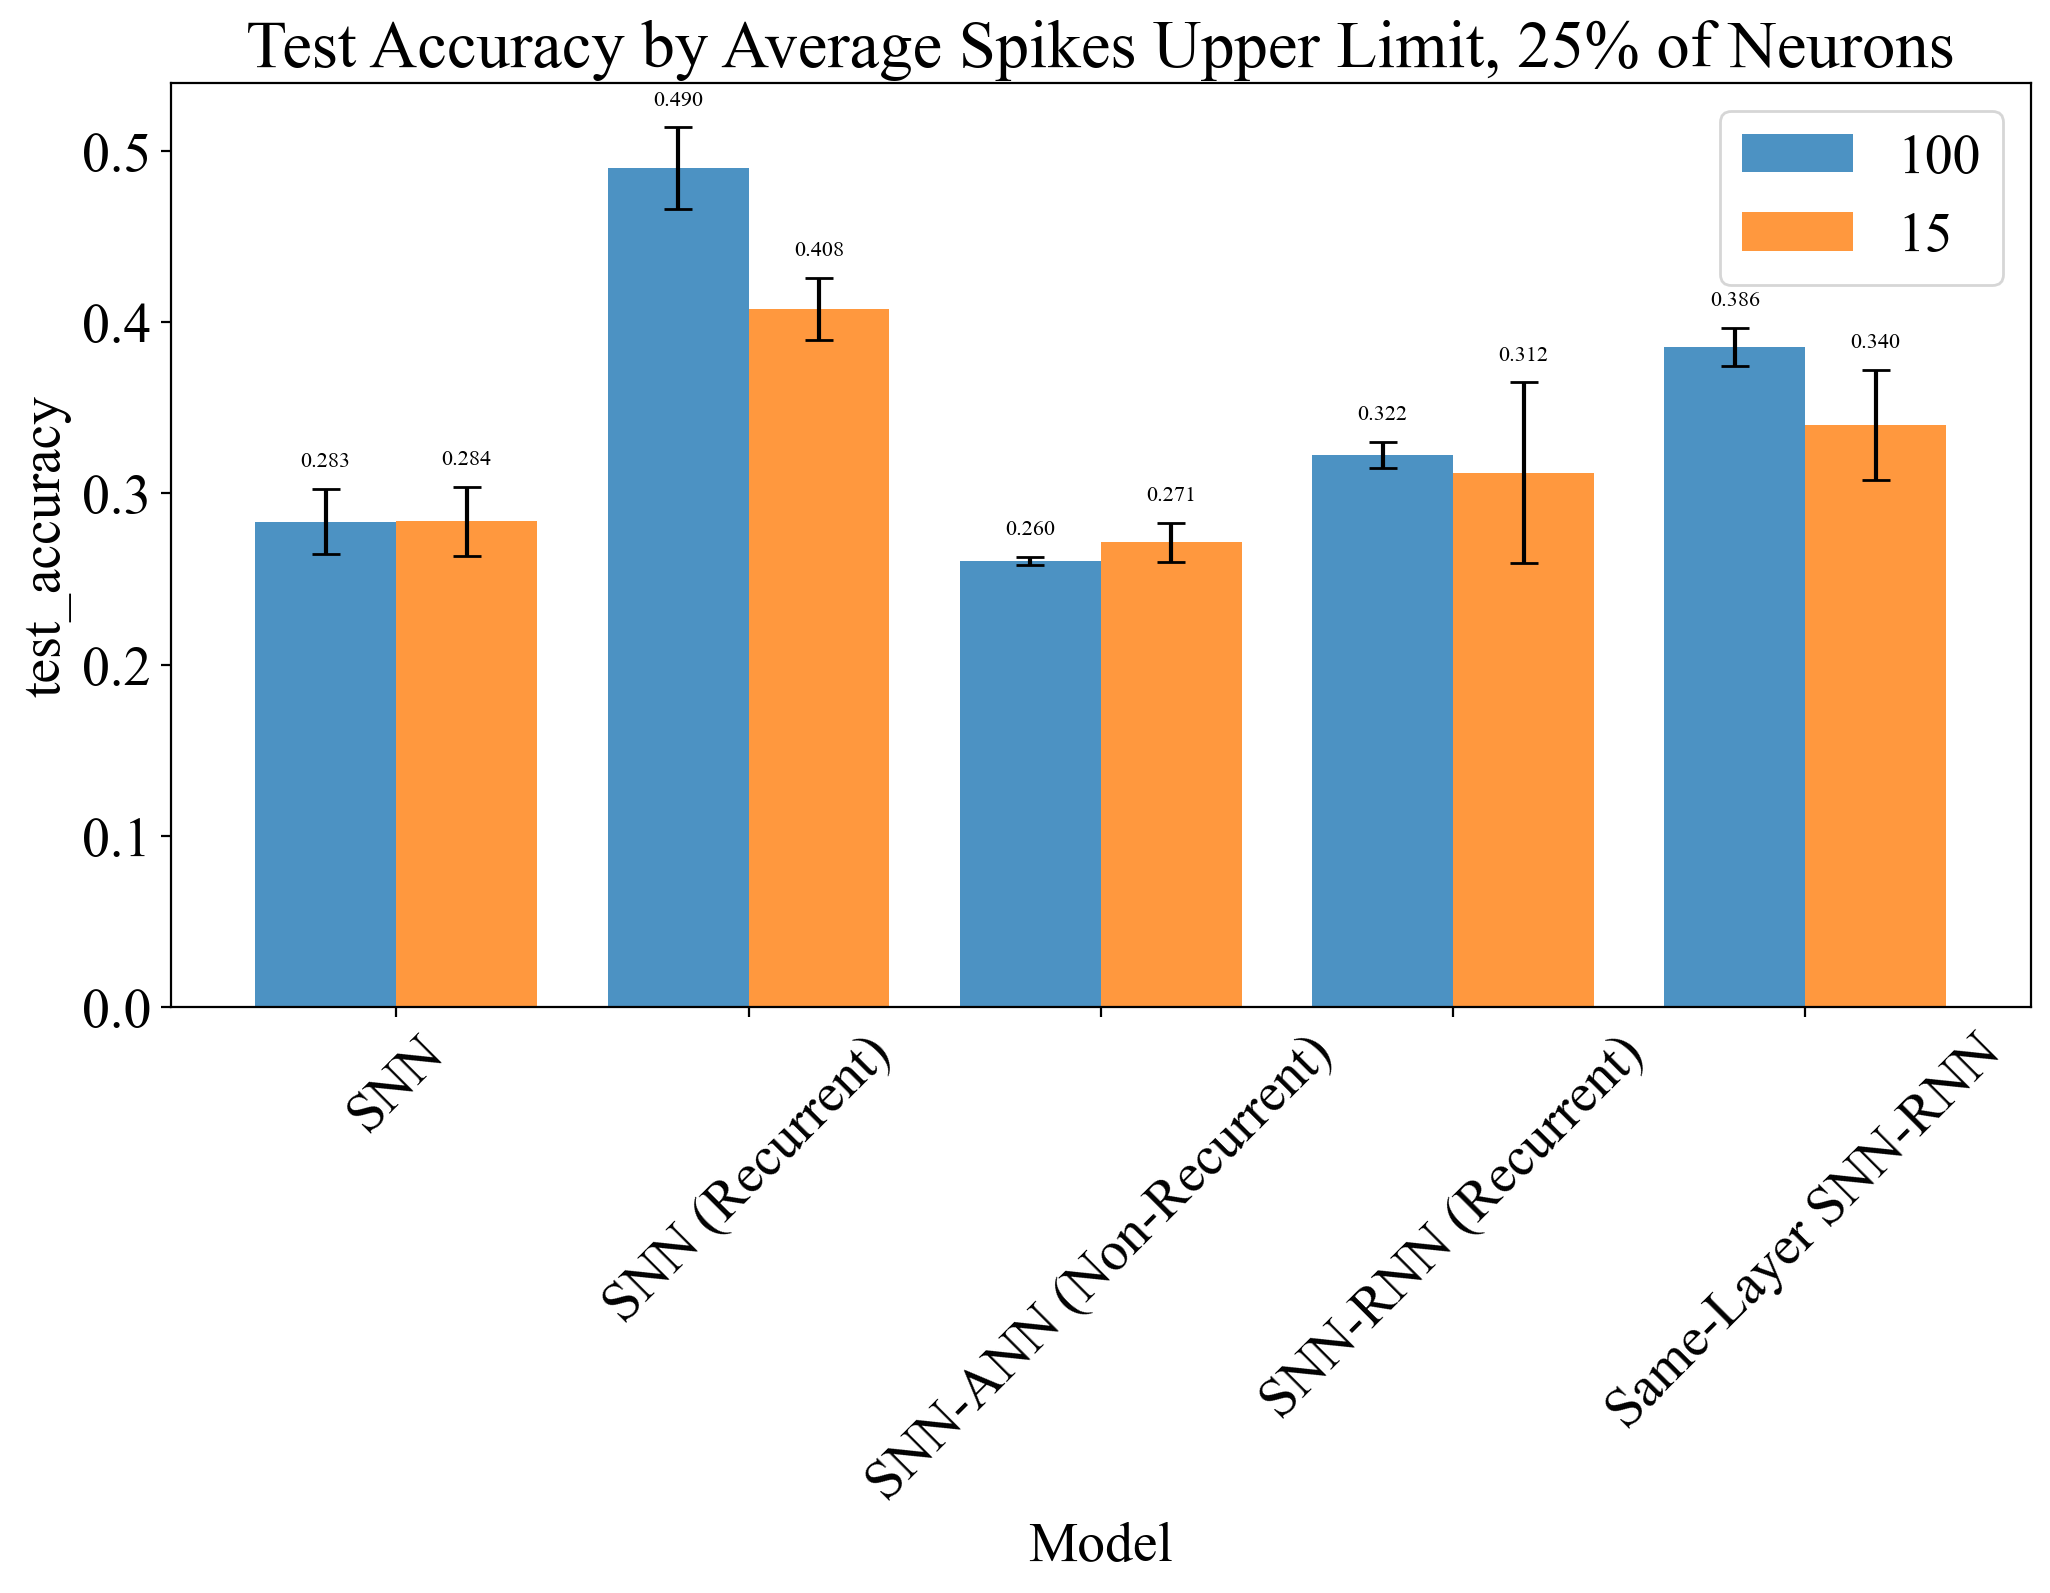

In [115]:
# Optimal SNN parameters - no upper bound
optimal_snn_params = {
    'v1_upper': [100, 15],
    'spike_grad_scale': [10], 
    'data_config.nb_hidden': 256,
    'data_config.percent_data': 0.25
}
filtered_means = filter_means(df_means, optimal_snn_params)
# Replace run_group values with remapped values
filtered_means['run_group'] = filtered_means['run_group'].replace(remapping)
# filtered_means['run_group'] = filtered_means['run_group'].replace(remapping)
param = 'v1_upper'
metric = 'test_accuracy'
plot_metric_distribution_param_based(param, optimal_snn_params[param], filtered_means, metric,  "Test Accuracy by Average Spikes Upper Limit, 25% of Neurons")

/var/folders/7b/0zqwym191dq_5jvhhbf5lfgr0000gn/T/ipykernel_23707/66394519.py:34: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_data = df_param[df_metric['run_group'] == group]
/var/folders/7b/0zqwym191dq_5jvhhbf5lfgr0000gn/T/ipykernel_23707/66394519.py:34: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_data = df_param[df_metric['run_group'] == group]
/var/folders/7b/0zqwym191dq_5jvhhbf5lfgr0000gn/T/ipykernel_23707/66394519.py:34: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_data = df_param[df_metric['run_group'] == group]
/var/folders/7b/0zqwym191dq_5jvhhbf5lfgr0000gn/T/ipykernel_23707/66394519.py:34: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  group_data = df_param[df_metric['run_group'] == group]
/var/folders/7b/0zqwym191dq_5jvhhbf5lfgr0000gn/T/ipykernel_23707/66394519.py:34: UserWarning: Boolean Series key will be reindexed to match Data

<Axes: title={'center': 'Test Accuracy for 100 Spike Upper Limit, by Percent of Data'}, xlabel='Model', ylabel='test_accuracy'>

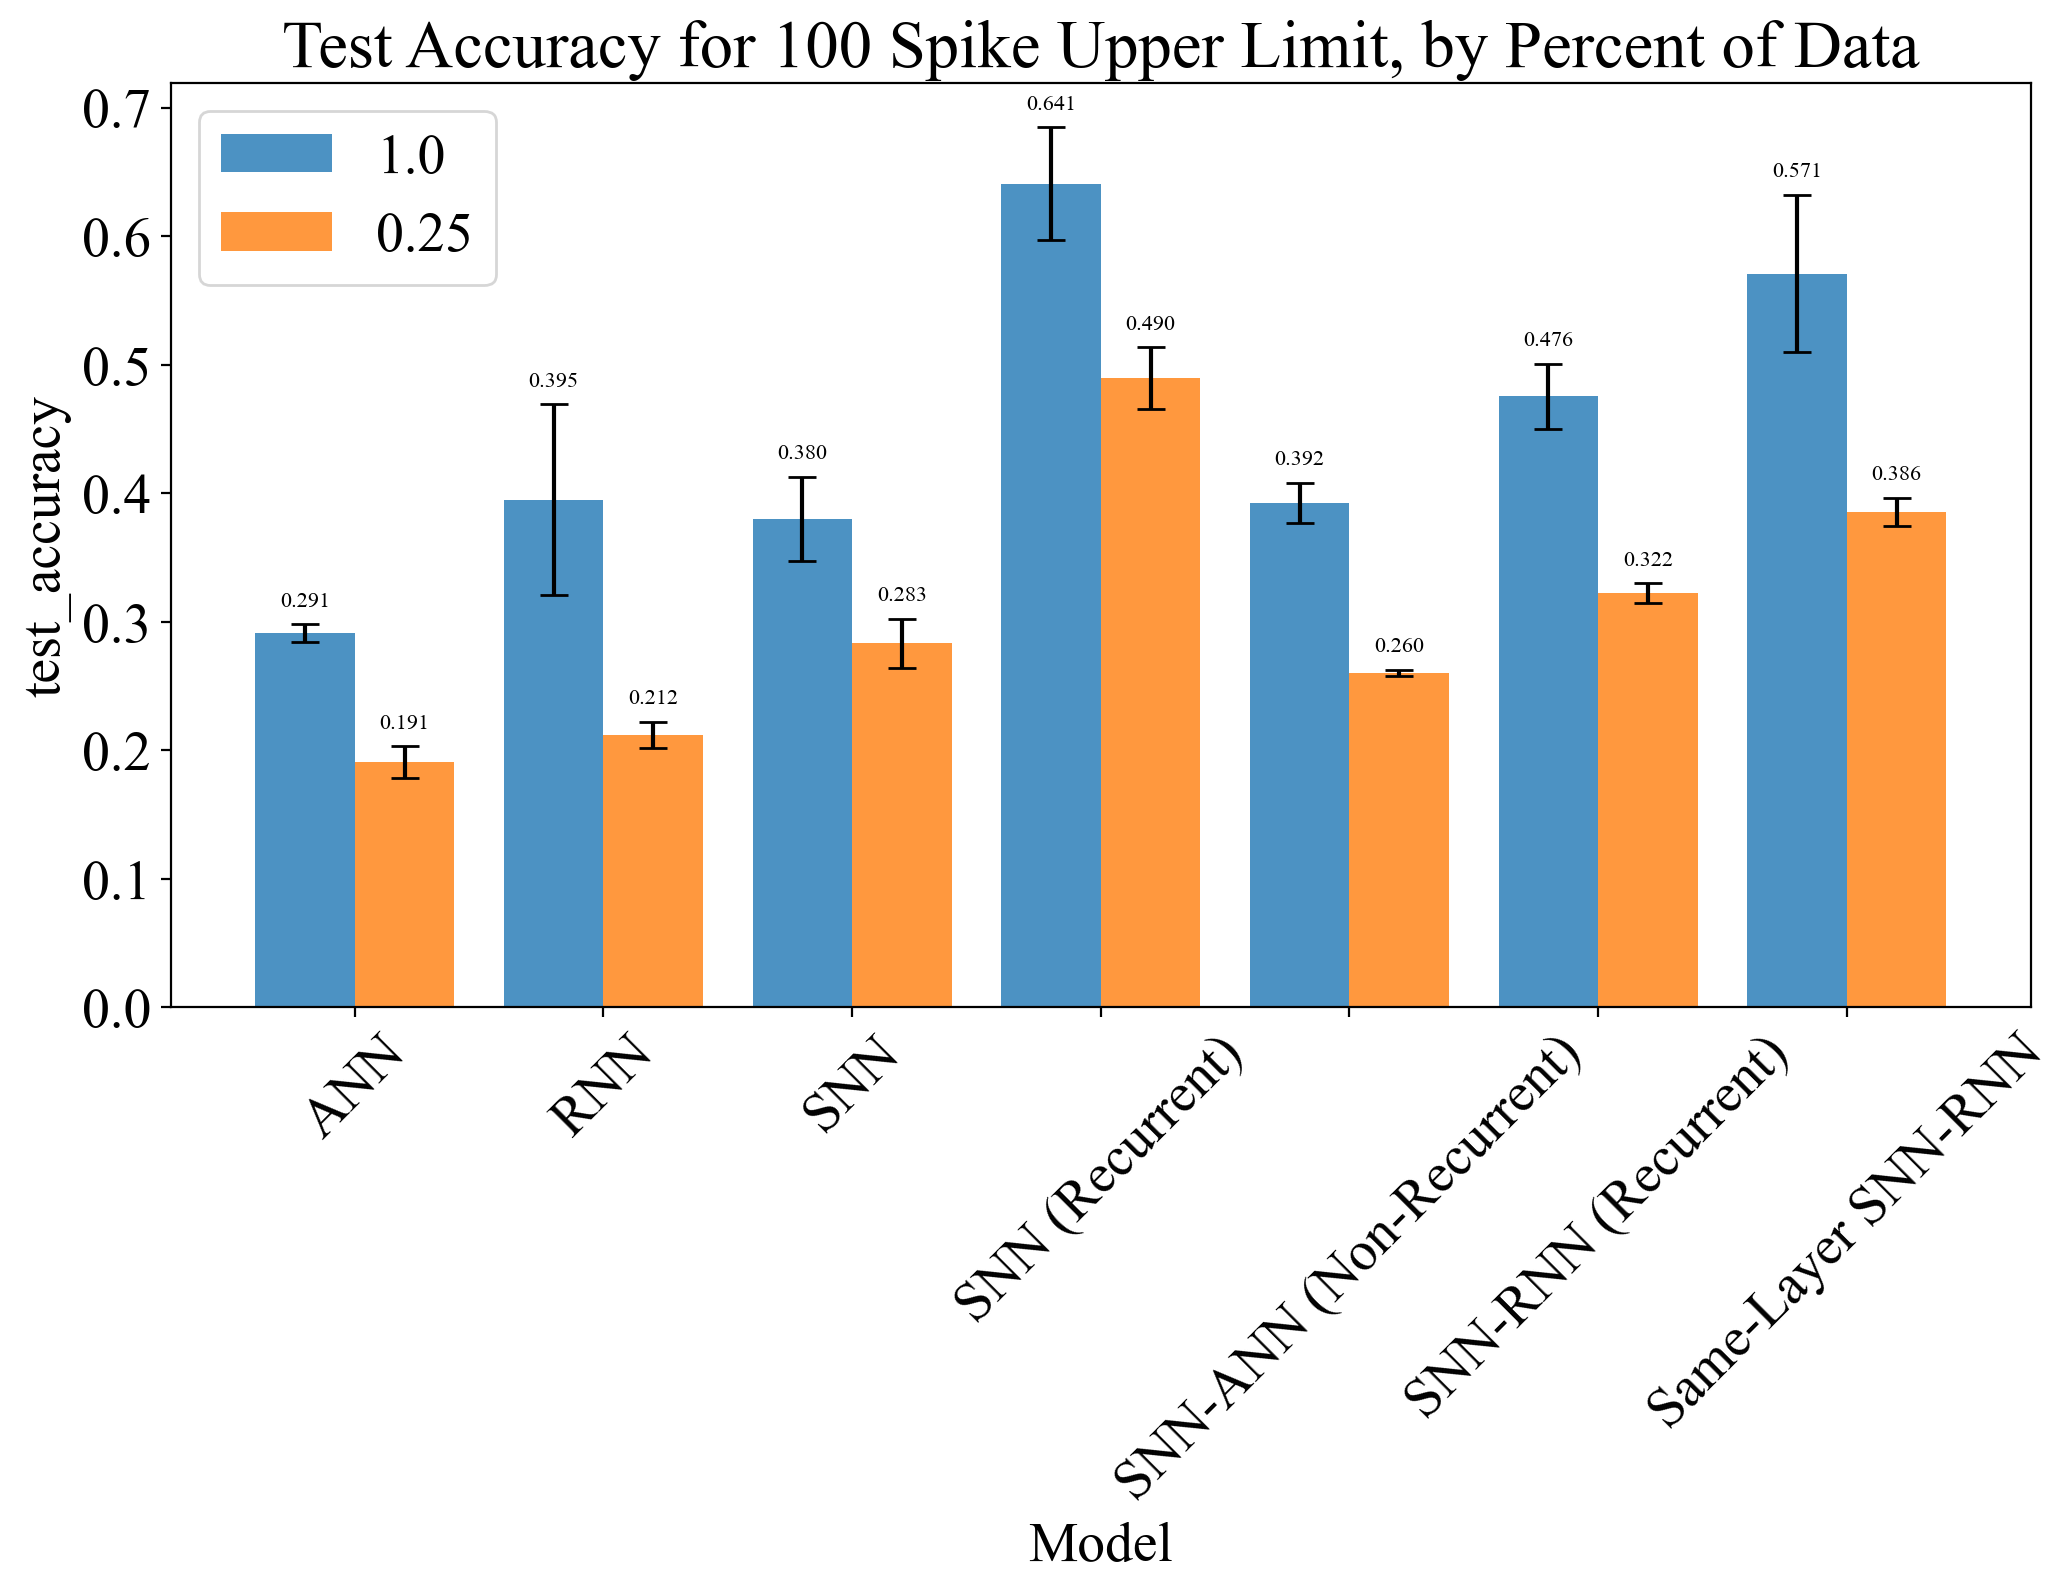

In [117]:
# Optimal SNN parameters - no upper bound
optimal_snn_params = {
    'v1_upper': [100, "Missing"],
    'spike_grad_scale': [10, "Missing"], 
    'data_config.nb_hidden': [256],
    'data_config.percent_data': [1.0, 0.25]
}
filtered_means = filter_means(df_means, optimal_snn_params)
# Replace run_group values with remapped values
filtered_means['run_group'] = filtered_means['run_group'].replace(remapping)
# filtered_means['run_group'] = filtered_means['run_group'].replace(remapping)
param = 'data_config.percent_data'
metric = 'test_accuracy'
plot_metric_distribution_param_based(param, optimal_snn_params[param], filtered_means, metric,  "Test Accuracy for 100 Spike Upper Limit, by Percent of Data")

<Axes: title={'center': 'Average Spikes Given 100 Average Spike Upper Limit, 25% of Data'}, xlabel='Model', ylabel='Value'>

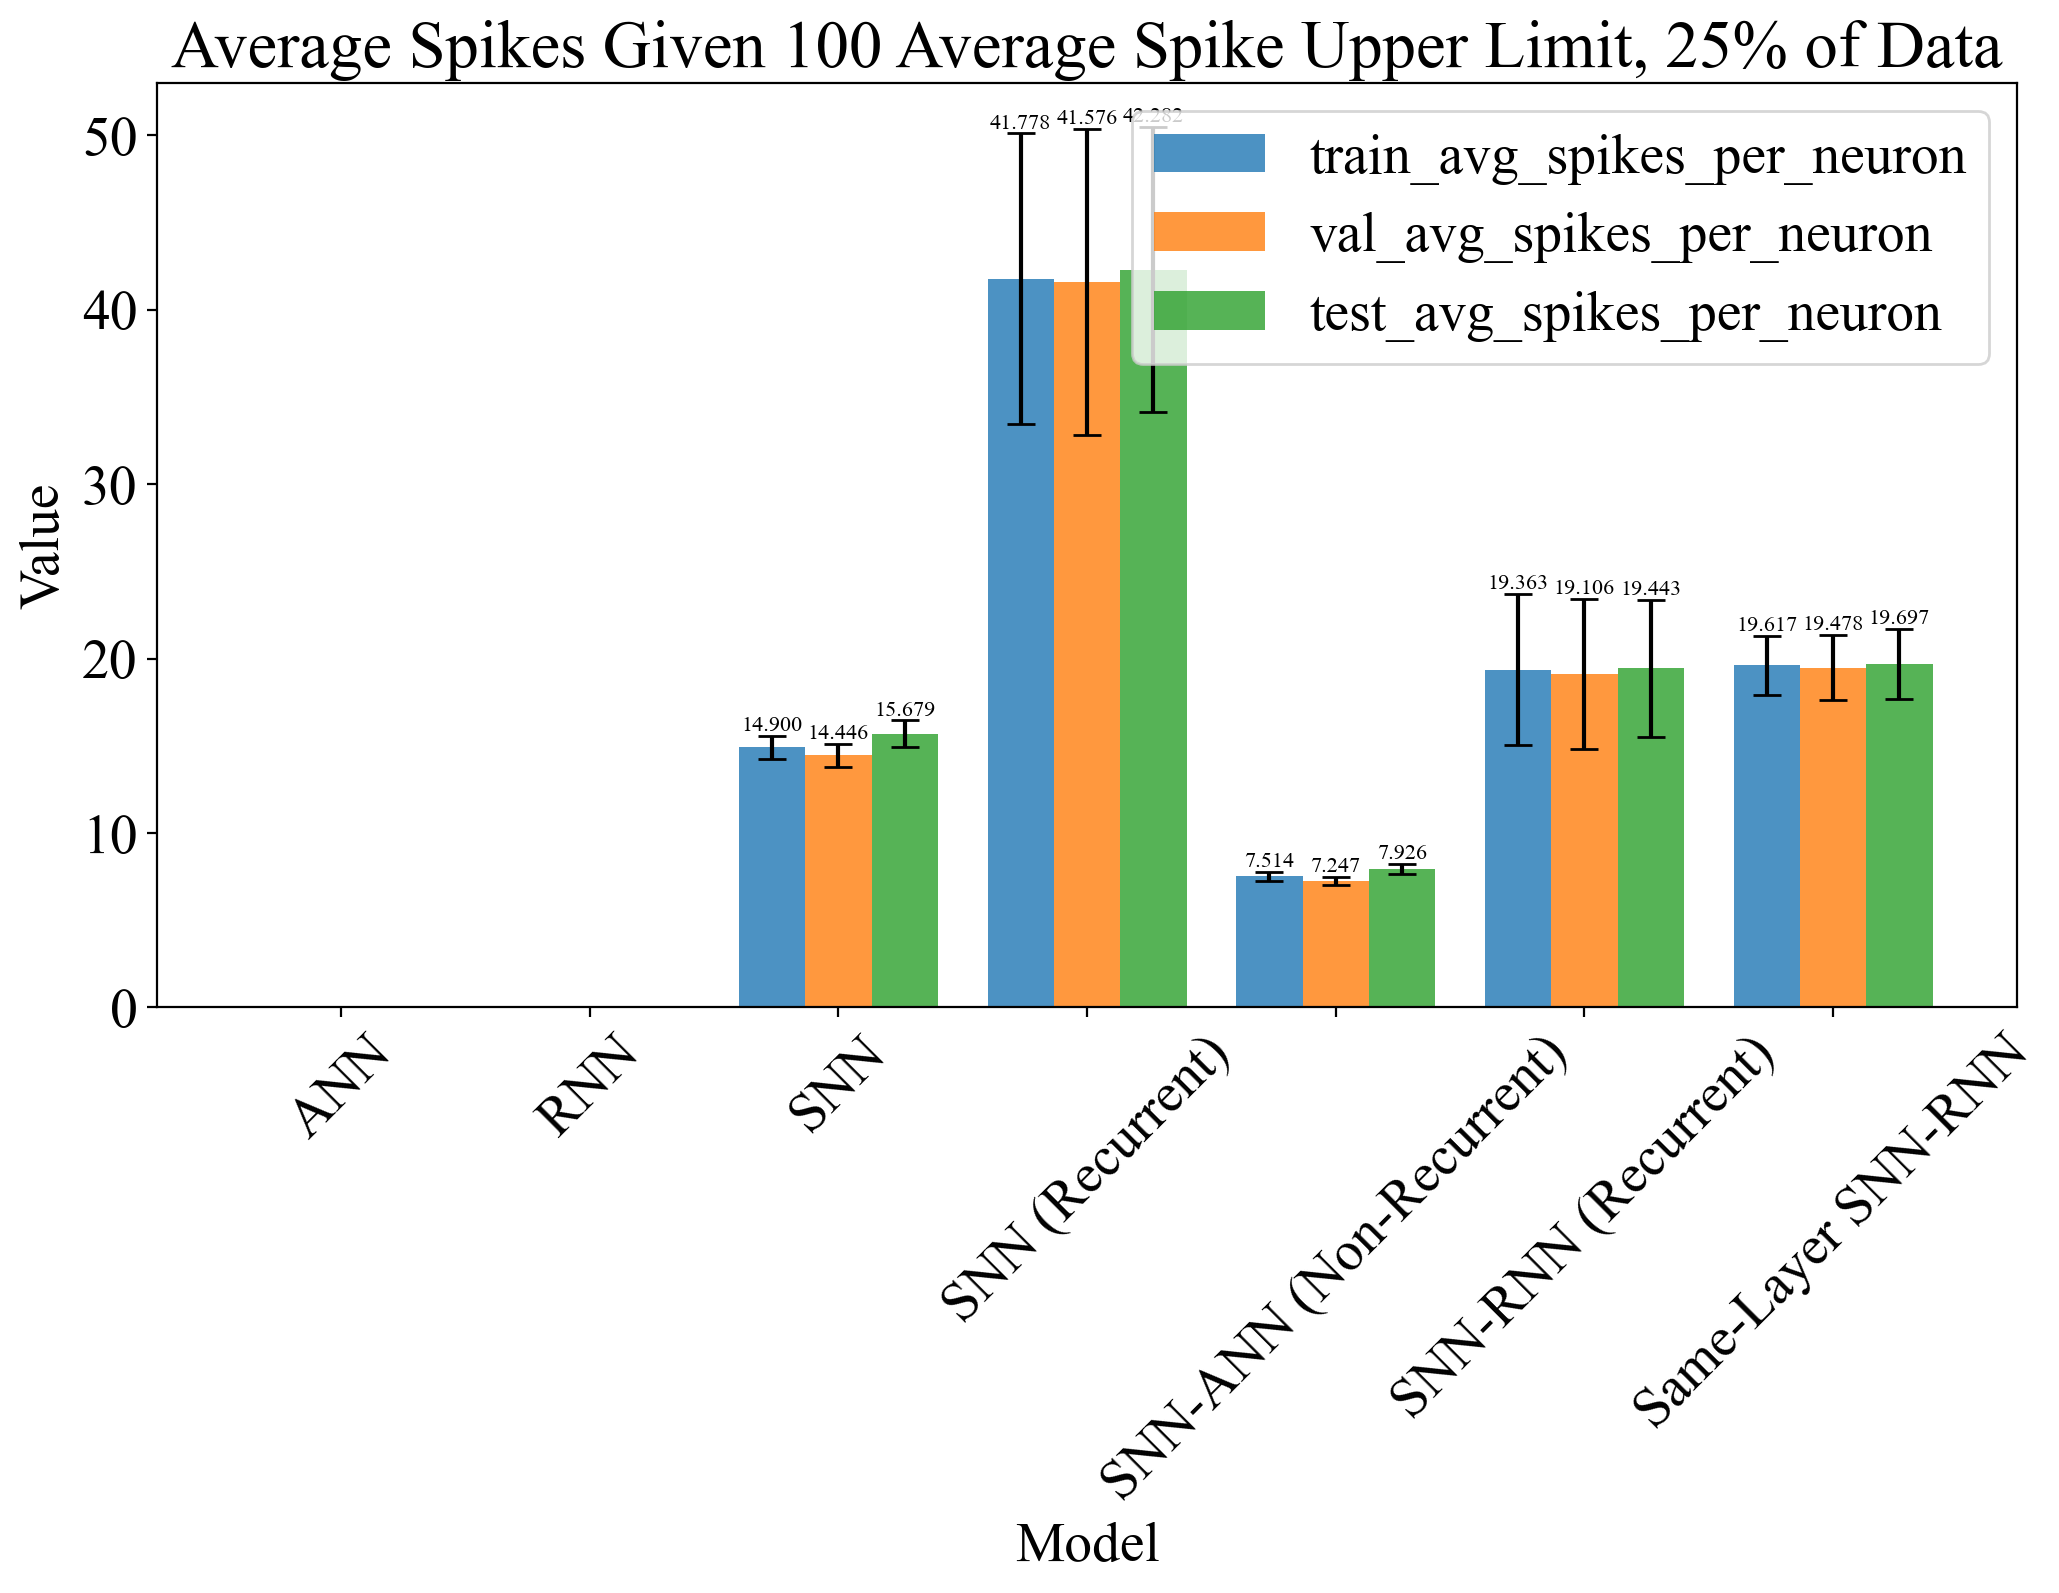

In [119]:
# Optimal SNN parameters - no upper bound
optimal_snn_params = {
    'v1_upper': [100, 'Missing'],
    'spike_grad_scale': [10, 'Missing'], 
    'data_config.nb_hidden': 256,
    'data_config.percent_data': 0.25
}
filtered_means = filter_means(df_means, optimal_snn_params)

remapping = {
    "SNN_rec_False_cross_entropy": "SNN",
    "SNN_rec_True_cross_entropy": "SNN (Recurrent)",
    "ANN_with_LIF_output_rec_False_cross_entropy": "ANN",
    "ANN_with_LIF_output_rec_True_cross_entropy": "RNN",
    "Hybrid_RNN_SNN_rec_rec_False_cross_entropy": "SNN-ANN (Non-Recurrent)",
    "Hybrid_RNN_SNN_rec_rec_True_cross_entropy": "SNN-RNN (Recurrent)",
    "Hybrid_RNN_SNN_V1_same_layer_rec_True_cross_entropy": "Same-Layer SNN-RNN",
}
# Replace run_group values with remapped values
filtered_means['run_group'] = filtered_means['run_group'].replace(remapping)
# filtered_means['run_group'] = filtered_means['run_group'].replace(remapping)
filtered_means[filtered_means['run_group'] == 'ANN']

metrics = ['train_avg_spikes_per_neuron', 'val_avg_spikes_per_neuron', 'test_avg_spikes_per_neuron']
plot_metric_distribution(filtered_means, metrics, title="Average Spikes Given 100 Average Spike Upper Limit, 25% of Data")